In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, sosfiltfilt, find_peaks, correlate
from scipy.stats import median_abs_deviation
from scipy.interpolate import CubicSpline
from scipy.ndimage import percentile_filter
from itertools import combinations
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display
import warnings
import matplotlib.font_manager as fm
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker

warnings.filterwarnings('ignore', category=UserWarning)

# ==========================================
#        MASTER CONFIGURATION
# ==========================================

# 1. FILE SETTINGS
INPUT_FOLDER = r'C:\Users\16171\Desktop\A20_ASAP7_KV\wake'          
SAVE_IMAGES = True          
NEGATIVE_GOING = True       

# 2. FRAME AVERAGING
FRAME_AVG_FACTOR = 2        

# 3. FILTERING & BASELINE
FILTER_ORDER = 5 
BASELINE_WINDOW_SEC = 0.05   
BASELINE_PERCENTILE = 20    
IGNORE_START_MS = 150       

# 4. COMPLEX SPIKE (CS) STREAM
CS_HIGH_CUT_HZ = 150.0      
CS_THRESHOLD_SIGMA = 6    
CS_MIN_DIST_MS = 25         

# 5. SIMPLE SPIKE (SS) STREAM
SS_LOW_CUT_HZ = 50       
SS_HIGH_CUT_HZ = 700   
SS_THRESHOLD_SIGMA = 2 
SS_MIN_DIST_MS = 2         
SS_BLANK_MS = 8                
SS_MIN_WIDTH_MS = 1        
SS_MAX_WIDTH_MS = 6.0      

# 6. LOCAL SNR FILTER (SS Only)
LOCAL_MIN_SNR = 1.5         
LOCAL_SNR_WINDOW_MS = 200  

# 7. VALID EPOCH DEFINITIONS
MAX_ALLOWED_GAP_MS = 50    
MIN_SEGMENT_MS = 200        
CORR_BIN_MS = 6           
DISPLAY_TOP_N_PAIRS = 3     

# 8. STIMULUS ANALYSIS (Puff)
PUFF_TIME_MS = 2500.0       
REC_DURATION_MS = 5000.0    

# 9. VISUALIZATION
PLOT_WINDOW_MS = [-50, 50]  

# --- PLOTTING STYLE FOR POSTERS ---
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False
})
STYLE = {'raw': '#333333', 'drift': '#FFC20A', 'cs': '#009E73', 'ss': '#D55E00', 'cs_th': '#56B4E9', 'ss_th': '#CC79A7'}

# ==========================================
# --- PROCESSING FUNCTIONS ---

def average_frames(trace, factor):
    if factor <= 1: return trace
    n_new = len(trace) // factor
    reshaped = trace[:n_new*factor].reshape(n_new, factor)
    return np.mean(reshaped, axis=1)

def estimate_noise_mad(trace):
    mad = median_abs_deviation(trace, scale='normal')
    return mad if mad > 0 else 1.0

def detrend_trace(trace, fs, window_sec=0.1, percentile=20):
    window_samples = int(window_sec * fs)
    if window_samples < 5: window_samples = 5
    baseline = percentile_filter(trace, percentile, size=window_samples)
    return trace - baseline

def apply_filter(trace, fs, low, high, order=2):
    nyquist = 0.5 * fs
    if high is not None and high >= nyquist: high = nyquist - 1.0
    if low is None and high is not None:
        sos = butter(order, high/nyquist, btype='low', output='sos')
    elif low is not None and high is not None:
        sos = butter(order, [low/nyquist, high/nyquist], btype='band', output='sos')
    elif low is not None and high is None:
        sos = butter(order, low/nyquist, btype='high', output='sos')
    else: return trace 
    return sosfiltfilt(sos, trace)

def validate_peaks_local_snr(peaks, raw_trace, fs, win_ms=100, min_snr=2.0):
    valid = []
    half_win = int((win_ms / 2.0 / 1000.0) * fs)
    n_points = len(raw_trace)
    for p in peaks:
        s = max(0, p - half_win)
        e = min(n_points, p + half_win)
        local_segment = raw_trace[s:e]
        if len(local_segment) < 10: continue
        threshold_exclude = np.percentile(np.abs(local_segment), 90)
        background_pixels = local_segment[np.abs(local_segment) < threshold_exclude]
        local_sigma = estimate_noise_mad(background_pixels) if len(background_pixels) >= 5 else estimate_noise_mad(local_segment)
        if (raw_trace[p] / local_sigma) >= min_snr: valid.append(p)
    return np.array(valid, dtype=int)

def process_purkinje_cell(raw_trace, fs, negative_going=False, filter_order=2):
    working_trace = raw_trace * -1 if negative_going else raw_trace
    detrended = detrend_trace(working_trace, fs, BASELINE_WINDOW_SEC, BASELINE_PERCENTILE)
    global_sigma = estimate_noise_mad(detrended)
    start_ignore_samples = int((IGNORE_START_MS / 1000.0) * fs)

    # CS Stream
    cs_trace = apply_filter(detrended, fs, None, CS_HIGH_CUT_HZ, order=filter_order)
    sigma_cs = estimate_noise_mad(cs_trace)
    cs_dist = int((CS_MIN_DIST_MS / 1000.0) * fs)
    cs_candidates, _ = find_peaks(cs_trace, height=CS_THRESHOLD_SIGMA * sigma_cs, distance=cs_dist)
    cs_peaks = cs_candidates[cs_candidates > start_ignore_samples]

    # SS Stream
    ss_trace_raw = apply_filter(detrended, fs, SS_LOW_CUT_HZ, SS_HIGH_CUT_HZ, order=filter_order)
    ss_trace_clean = ss_trace_raw.copy()
    blank_samples = int((SS_BLANK_MS / 1000.0) * fs)
    for cs_idx in cs_peaks:
        start = max(0, cs_idx - int(0.005*fs)) 
        end = min(len(raw_trace), start + blank_samples)
        ss_trace_clean[start:end] = 0 
    valid_ss = ss_trace_clean[ss_trace_clean != 0]
    sigma_ss_filtered = estimate_noise_mad(valid_ss) if len(valid_ss) > 0 else 1.0
    ss_dist = int((SS_MIN_DIST_MS / 1000.0) * fs)
    w_min = (SS_MIN_WIDTH_MS / 1000.0) * fs; w_max = (SS_MAX_WIDTH_MS / 1000.0) * fs
    ss_candidates, _ = find_peaks(ss_trace_clean, height=SS_THRESHOLD_SIGMA * sigma_ss_filtered, distance=ss_dist, width=(w_min, w_max), rel_height=0.5)
    ss_candidates = ss_candidates[ss_candidates > start_ignore_samples]
    ss_peaks = validate_peaks_local_snr(ss_candidates, detrended, fs, win_ms=LOCAL_SNR_WINDOW_MS, min_snr=LOCAL_MIN_SNR)
    
    return {
        'detrended': detrended, 'cs_trace': cs_trace, 'cs_peaks': cs_peaks,
        'ss_trace': ss_trace_clean, 'ss_peaks': ss_peaks,
        'sigma_cs': sigma_cs, 'sigma_ss': sigma_ss_filtered, 'raw_sigma': global_sigma
    }

# --- STATS HELPERS ---
def get_interpolated_wave(wave, fs, upscale_factor=10):
    n_points = len(wave)
    x_new = np.linspace(0, n_points - 1, n_points * upscale_factor)
    cs = CubicSpline(np.arange(n_points), wave)
    return x_new, cs(x_new)

def get_wave_stats(wave, time_axis_ms):
    peak_idx = np.argmax(wave)
    baseline = np.mean(wave[:5]) 
    amp = wave[peak_idx] - baseline
    half_height = baseline + (amp / 2.0)
    crossings = np.where(np.diff(np.sign(wave - half_height)))[0]
    fwhm = np.nan
    if len(crossings) >= 2:
        left = crossings[crossings < peak_idx]; right = crossings[crossings >= peak_idx]
        if len(left) > 0 and len(right) > 0: fwhm = time_axis_ms[right[0]] - time_axis_ms[left[-1]]
    return amp, fwhm

print("Config & Functions Loaded.")

Config & Functions Loaded.


In [2]:
xlsx_files = [f for f in glob.glob(os.path.join(INPUT_FOLDER, "*.xlsx")) 
              if not os.path.basename(f).startswith('~$')]
xlsx_files.sort()
last_data_package = {}

print(f"Found {len(xlsx_files)} files. Processing...")

for file_path in xlsx_files:
    try:
        base_name = os.path.splitext(os.path.basename(file_path))[0]
        output_dir = os.path.join(INPUT_FOLDER, base_name)
        os.makedirs(output_dir, exist_ok=True)

        df = pd.read_excel(file_path, sheet_name='Sheet1', engine='openpyxl')
        time_vec_raw = df.iloc[:, 0].values.astype(float)
        raw_matrix_full = df.iloc[:, 1:].values.astype(float)
        cell_names = df.columns[1:].tolist()

        if FRAME_AVG_FACTOR > 1:
            raw_matrix = np.apply_along_axis(average_frames, 0, raw_matrix_full, factor=FRAME_AVG_FACTOR)
            time_vec = time_vec_raw[::FRAME_AVG_FACTOR]
            if len(time_vec) > len(raw_matrix): time_vec = time_vec[:len(raw_matrix)]
        else: raw_matrix = raw_matrix_full; time_vec = time_vec_raw
        dt_ms = np.median(np.diff(time_vec)); fs = 1000.0 / dt_ms
        n_cells = len(cell_names); results = [] 
        
        for i in range(n_cells):
            res = process_purkinje_cell(raw_matrix[:, i], fs, NEGATIVE_GOING, FILTER_ORDER)
            if NEGATIVE_GOING:
                trace_orig = raw_matrix[:, i]
                drift_inv = detrend_trace(trace_orig * -1, fs, BASELINE_WINDOW_SEC, BASELINE_PERCENTILE)
                res['baseline'] = ((trace_orig * -1) - drift_inv) * -1
            else: res['baseline'] = raw_matrix[:, i] - res['detrended']
            results.append(res)

        cs_traces = np.column_stack([r['cs_trace'] for r in results])
        ss_traces = np.column_stack([r['ss_trace'] for r in results])
        spike_times_cs = np.array([time_vec[r['cs_peaks']] for r in results], dtype=object)
        spike_times_ss = np.array([time_vec[r['ss_peaks']] for r in results], dtype=object)
        sigmas = np.array([r['raw_sigma'] for r in results])

        npz_path = os.path.join(output_dir, f"{base_name}_analyzed.npz")
        np.savez_compressed(npz_path, time_ms=time_vec, raw_data=raw_matrix,
                            cs_traces=cs_traces, ss_traces=ss_traces,
                            spike_times_cs=spike_times_cs, spike_times_ss=spike_times_ss,
                            cell_names=cell_names, fs=fs, raw_sigmas=sigmas)
        
        last_data_package = {'name': base_name, 'time': time_vec, 'raw_data': raw_matrix, 
                             'results': results, 'cells': cell_names, 'fs': fs}
        print(f"Processed: {base_name}")
    except Exception as e: print(f"ERROR: {file_path} -> {e}")

Found 1 files. Processing...
Processed: Simple_spikes_raw_trace


>>> INSPECTION: Simple_spikes_raw_trace


Output()


============================== SPIKE STATISTICS ==============================


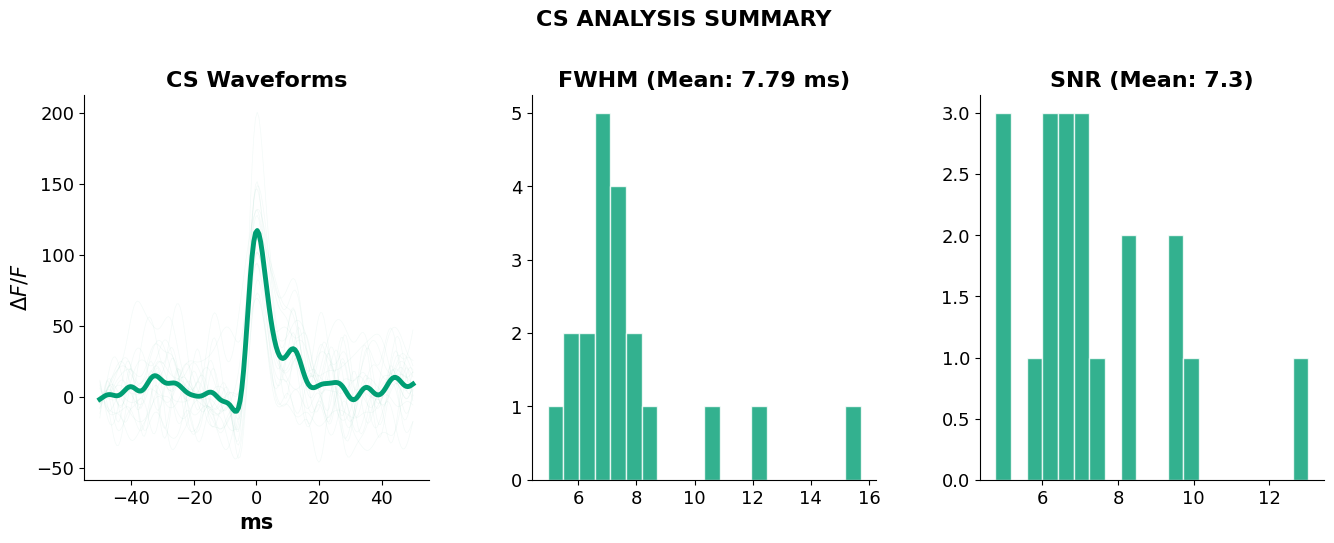

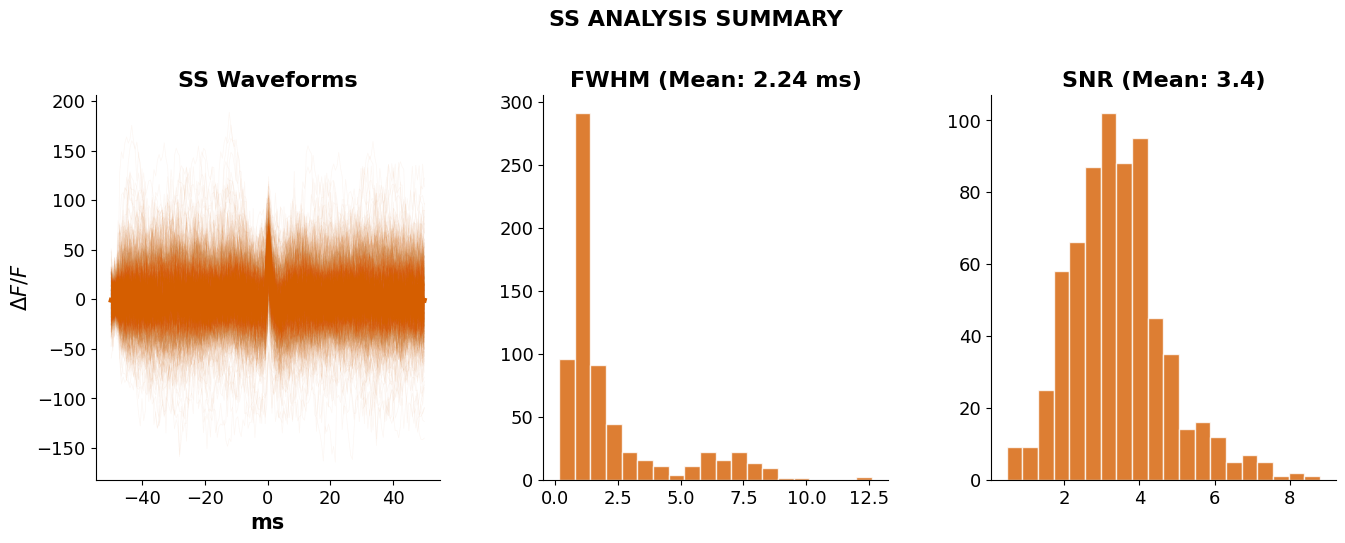

In [ ]:
N_BACKGROUND_TRACES = 2000 

if not 'last_data_package' in globals() or not last_data_package:
    print("No data. Run Block 2.")
else:
    print(f">>> INSPECTION: {last_data_package['name']}")
    
    # --- 1. SLIDER PLOT ---
    pkg = last_data_package; t_min, t_max = pkg['time'][0], pkg['time'][-1]
    slider_time = widgets.FloatRangeSlider(value=[t_min, min(t_min + 500, t_max)], min=t_min, max=t_max, step=10, description='Time:', layout=widgets.Layout(width='90%'))
    slider_zoom = widgets.FloatSlider(value=5.0, min=1.0, max=50.0, step=1.0, description='Y-Zoom:')
    plot_output = widgets.Output()

    def update_plot(change=None):
        time_range = slider_time.value; y_scale = slider_zoom.value
        with plot_output:
            plot_output.clear_output(wait=True)
            t = pkg['time']; raw_matrix = pkg['raw_data']
            mask = (t >= time_range[0]) & (t <= time_range[1])
            if np.sum(mask) < 2: return
            n_cells = len(pkg['cells'])
            fig, axes = plt.subplots(n_cells, 3, figsize=(15, 3 * n_cells), sharex=True)
            if n_cells == 1: axes = axes.reshape(1, -1)
            
            for i in range(n_cells):
                res = pkg['results'][i]
                thresh_cs = CS_THRESHOLD_SIGMA * res['sigma_cs']; thresh_ss = SS_THRESHOLD_SIGMA * res['sigma_ss']
                valid_cs = res['cs_peaks'][(t[res['cs_peaks']] >= time_range[0]) & (t[res['cs_peaks']] <= time_range[1])]
                valid_ss = res['ss_peaks'][(t[res['ss_peaks']] >= time_range[0]) & (t[res['ss_peaks']] <= time_range[1])]

                # Raw & Baseline
                axes[i, 0].plot(t[mask], raw_matrix[mask, i], color=STYLE['raw'], alpha=0.5, lw=1)
                axes[i, 0].plot(t[mask], res['baseline'][mask], color=STYLE['drift'], ls='--', alpha=0.6)
                if len(valid_cs) > 0: axes[i, 0].plot(t[valid_cs], raw_matrix[valid_cs, i], 'x', color='k', ms=8, mew=2)
                if len(valid_ss) > 0: axes[i, 0].plot(t[valid_ss], raw_matrix[valid_ss, i], '.', color=STYLE['ss'], ms=3)
                
                # Format: No Grid, Clean Spines
                axes[i, 0].set_title(f"{pkg['cells'][i]} Raw", fontweight='bold')
                axes[i, 0].spines['top'].set_visible(False)
                axes[i, 0].spines['right'].set_visible(False)

                # CS Stream
                axes[i, 1].plot(t[mask], res['cs_trace'][mask], color=STYLE['cs'])
                axes[i, 1].axhline(thresh_cs, color=STYLE['cs_th'], ls='--')
                axes[i, 1].set_title(f"CS Stream", fontweight='bold')
                axes[i, 1].spines['top'].set_visible(False)
                axes[i, 1].spines['right'].set_visible(False)
                
                # SS Stream
                axes[i, 2].plot(t[mask], res['ss_trace'][mask], color=STYLE['ss'])
                axes[i, 2].axhline(thresh_ss, color=STYLE['ss_th'], ls='--')
                axes[i, 2].set_title(f"SS Stream", fontweight='bold')
                axes[i, 2].spines['top'].set_visible(False)
                axes[i, 2].spines['right'].set_visible(False)
                
                # Y-Lim Scaling
                for a, trace, th in zip([axes[i, 1], axes[i, 2]], [res['cs_trace'][mask], res['ss_trace'][mask]], [thresh_cs, thresh_ss]):
                    local_std = np.std(trace) if len(trace) > 0 else 1.0
                    limit = max((30.0/y_scale)*local_std, th*1.5)
                    a.set_ylim(-limit, limit)
                    # NO GRID as requested
            
            plt.tight_layout(); plt.show()
    
    slider_time.observe(update_plot, names='value'); slider_zoom.observe(update_plot, names='value')
    update_plot(); display(widgets.VBox([slider_time, slider_zoom]), plot_output)

    # --- 2. SPIKE STATS REPORT (POSTER STYLE) ---
    print("\n" + "="*30 + " SPIKE STATISTICS " + "="*30)
    fs = pkg['fs']; win = [int(PLOT_WINDOW_MS[0]*fs/1000), int(PLOT_WINDOW_MS[1]*fs/1000)]
    explen = win[1] - win[0]

    for spike_type in ['CS', 'SS']:
        all_waves = []; stats = {'fwhm': [], 'snr': []}
        
        for i in range(len(pkg['cells'])):
            res = pkg['results'][i]
            trace = res['cs_trace'] if spike_type == 'CS' else res['detrended']
            peaks = res['cs_peaks'] if spike_type == 'CS' else res['ss_peaks']
            sigma = res['sigma_cs'] if spike_type == 'CS' else res['raw_sigma']
            
            subset = peaks if len(peaks) < N_BACKGROUND_TRACES else np.random.choice(peaks, N_BACKGROUND_TRACES, replace=False)
            for p in subset:
                s, e = p + win[0], p + win[1]
                if s >= 0 and e < len(trace):
                    wave = trace[s:e]
                    if len(wave) == explen:
                        wave = wave - np.mean(wave[:5])
                        all_waves.append(wave)
                        stats['snr'].append(np.max(wave)/sigma)
                        _, w_s = get_interpolated_wave(wave, fs)
                        t_d = np.linspace(PLOT_WINDOW_MS[0], PLOT_WINDOW_MS[1], len(w_s))
                        _, fwhm = get_wave_stats(w_s, t_d)
                        if not np.isnan(fwhm): stats['fwhm'].append(fwhm)

        if len(all_waves) > 0:
            fig = plt.figure(figsize=(16, 5))
            gs = fig.add_gridspec(1, 3, wspace=0.3)
            
            # 1. Waveforms
            ax1 = fig.add_subplot(gs[0])
            t_ms = np.linspace(PLOT_WINDOW_MS[0], PLOT_WINDOW_MS[1], len(all_waves[0]))
            # Light background traces
            for w in all_waves[:N_BACKGROUND_TRACES]:
                ax1.plot(t_ms, w, color=STYLE[spike_type.lower()], alpha=0.05, lw=0.5)
            # Thick average line
            ax1.plot(t_ms, np.mean(all_waves, axis=0), color=STYLE[spike_type.lower()], lw=3.5)
            ax1.set_title(f"{spike_type} Waveforms", fontweight='bold')
            ax1.set_xlabel("ms", fontweight='bold')
            ax1.set_ylabel("$\Delta F/F$", fontweight='bold')
            ax1.spines['top'].set_visible(False)
            ax1.spines['right'].set_visible(False)
            
            # 2. FWHM Hist
            ax2 = fig.add_subplot(gs[1])
            ax2.hist(stats['fwhm'], bins=20, color=STYLE[spike_type.lower()], alpha=0.8, edgecolor='white')
            ax2.set_title(f"FWHM (Mean: {np.nanmean(stats['fwhm']):.2f} ms)", fontweight='bold')
            ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
            
            # 3. SNR Hist
            ax3 = fig.add_subplot(gs[2])
            ax3.hist(stats['snr'], bins=20, color=STYLE[spike_type.lower()], alpha=0.8, edgecolor='white')
            ax3.set_title(f"SNR (Mean: {np.mean(stats['snr']):.1f})", fontweight='bold')
            ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)
            
            plt.suptitle(f"{spike_type} ANALYSIS SUMMARY", fontweight='bold', fontsize=16, y=1.05)
            plt.show()

In [4]:
def get_valid_intervals(spike_times, max_gap, t_start, t_end):
    if len(spike_times) < 2: return []
    isis = np.diff(spike_times)
    gap_indices = np.where(isis > max_gap)[0]
    valid_segments = []
    current_start = spike_times[0]
    for gap_idx in gap_indices:
        current_end = spike_times[gap_idx]
        valid_segments.append((current_start, current_end))
        current_start = spike_times[gap_idx + 1]
    valid_segments.append((current_start, spike_times[-1]))
    return valid_segments

def intersect_intervals(intervals_a, intervals_b):
    overlaps = []
    i, j = 0, 0
    while i < len(intervals_a) and j < len(intervals_b):
        start_a, end_a = intervals_a[i]; start_b, end_b = intervals_b[j]
        low = max(start_a, start_b); high = min(end_a, end_b)
        if low < high: overlaps.append((low, high))
        if end_a < end_b: i += 1
        else: j += 1
    return overlaps

def compute_pair_stats(times_1, times_2, bin_ms, max_lag_ms=100):
    if len(times_1) == 0 or len(times_2) == 0:
        return 0.0, np.linspace(-max_lag_ms, max_lag_ms, int(2*max_lag_ms/bin_ms)+1), np.zeros(int(2*max_lag_ms/bin_ms)+1)
    
    t_min = min(times_1[0], times_2[0]); t_max = max(times_1[-1], times_2[-1])
    edges = np.arange(t_min, t_max + bin_ms, bin_ms)
    b1, _ = np.histogram(times_1, bins=edges); b2, _ = np.histogram(times_2, bins=edges)
    
    if np.std(b1) == 0 or np.std(b2) == 0: pearson_r = 0.0
    else: pearson_r = np.corrcoef(b1, b2)[0, 1]

    xcorr = correlate(b1 - np.mean(b1), b2 - np.mean(b2), mode='full')
    norm = np.std(b1) * np.std(b2) * len(b1)
    xcorr = np.zeros_like(xcorr) if norm == 0 else xcorr / norm
    lags = np.arange(-len(b1) + 1, len(b1)) * bin_ms
    mask = (lags >= -max_lag_ms) & (lags <= max_lag_ms)
    return pearson_r, lags[mask], xcorr[mask]

def compute_significance_shuffle(times_1, times_2, bin_ms, duration_ms, real_r, n_shuffles=1000):
    if len(times_1) < 10 or len(times_2) < 10: return 1.0, 0.0, []
    shuffled_rs = []
    t_min = min(times_1[0], times_2[0])
    edges = np.arange(t_min, t_min + duration_ms + bin_ms, bin_ms)
    b1, _ = np.histogram(times_1, bins=edges)
    if np.std(b1) == 0: return 1.0, 0.0, []
    
    for _ in range(n_shuffles):
        shift = np.random.uniform(1000, duration_ms - 1000)
        shifted_t2 = (times_2 + shift) 
        shifted_t2 = np.where(shifted_t2 > (t_min + duration_ms), shifted_t2 - duration_ms, shifted_t2)
        b2_shuff, _ = np.histogram(shifted_t2, bins=edges)
        if np.std(b2_shuff) > 0:
            shuffled_rs.append(np.corrcoef(b1, b2_shuff)[0, 1])
        else:
            shuffled_rs.append(0)
            
    shuffled_rs = np.array(shuffled_rs)
    if real_r >= 0: p_val = (np.sum(shuffled_rs >= real_r) + 1) / (n_shuffles + 1)
    else: p_val = (np.sum(shuffled_rs <= real_r) + 1) / (n_shuffles + 1)
    
    z_score = (real_r - np.mean(shuffled_rs)) / (np.std(shuffled_rs) + 1e-9)
    return p_val, z_score, shuffled_rs

def calculate_coverage_depth(all_cell_intervals):
    events = []
    for intervals in all_cell_intervals:
        for start, end in intervals:
            events.append((start, 1)); events.append((end, -1))
    events.sort(key=lambda x: x[0])
    coverage_segments = []; current_depth = 0; prev_time = events[0][0]
    for t, change in events:
        if t > prev_time: coverage_segments.append((prev_time, t, current_depth))
        current_depth += change
        prev_time = t
    return coverage_segments

In [5]:
def get_valid_intervals(spike_times, max_gap, t_start, t_end):
    if len(spike_times) < 2: return []
    isis = np.diff(spike_times)
    gap_indices = np.where(isis > max_gap)[0]
    valid_segments = []
    current_start = spike_times[0]
    for gap_idx in gap_indices:
        current_end = spike_times[gap_idx]
        valid_segments.append((current_start, current_end))
        current_start = spike_times[gap_idx + 1]
    valid_segments.append((current_start, spike_times[-1]))
    return valid_segments

def intersect_intervals(intervals_a, intervals_b):
    overlaps = []
    i, j = 0, 0
    while i < len(intervals_a) and j < len(intervals_b):
        start_a, end_a = intervals_a[i]; start_b, end_b = intervals_b[j]
        low = max(start_a, start_b); high = min(end_a, end_b)
        if low < high: overlaps.append((low, high))
        if end_a < end_b: i += 1
        else: j += 1
    return overlaps

def compute_pair_stats(times_1, times_2, bin_ms, max_lag_ms=100):
    if len(times_1) == 0 or len(times_2) == 0:
        return 0.0, np.linspace(-max_lag_ms, max_lag_ms, int(2*max_lag_ms/bin_ms)+1), np.zeros(int(2*max_lag_ms/bin_ms)+1)
    
    t_min = min(times_1[0], times_2[0]); t_max = max(times_1[-1], times_2[-1])
    edges = np.arange(t_min, t_max + bin_ms, bin_ms)
    b1, _ = np.histogram(times_1, bins=edges); b2, _ = np.histogram(times_2, bins=edges)
    
    if np.std(b1) == 0 or np.std(b2) == 0: pearson_r = 0.0
    else: pearson_r = np.corrcoef(b1, b2)[0, 1]

    xcorr = correlate(b1 - np.mean(b1), b2 - np.mean(b2), mode='full')
    norm = np.std(b1) * np.std(b2) * len(b1)
    xcorr = np.zeros_like(xcorr) if norm == 0 else xcorr / norm
    lags = np.arange(-len(b1) + 1, len(b1)) * bin_ms
    mask = (lags >= -max_lag_ms) & (lags <= max_lag_ms)
    return pearson_r, lags[mask], xcorr[mask]

def compute_significance_shuffle(times_1, times_2, bin_ms, duration_ms, real_r, n_shuffles=1000):
    if len(times_1) < 10 or len(times_2) < 10: return 1.0, 0.0, []
    shuffled_rs = []
    t_min = min(times_1[0], times_2[0])
    edges = np.arange(t_min, t_min + duration_ms + bin_ms, bin_ms)
    b1, _ = np.histogram(times_1, bins=edges)
    if np.std(b1) == 0: return 1.0, 0.0, []
    
    for _ in range(n_shuffles):
        shift = np.random.uniform(1000, duration_ms - 1000)
        shifted_t2 = (times_2 + shift) 
        shifted_t2 = np.where(shifted_t2 > (t_min + duration_ms), shifted_t2 - duration_ms, shifted_t2)
        b2_shuff, _ = np.histogram(shifted_t2, bins=edges)
        if np.std(b2_shuff) > 0:
            shuffled_rs.append(np.corrcoef(b1, b2_shuff)[0, 1])
        else:
            shuffled_rs.append(0)
            
    shuffled_rs = np.array(shuffled_rs)
    if real_r >= 0: p_val = (np.sum(shuffled_rs >= real_r) + 1) / (n_shuffles + 1)
    else: p_val = (np.sum(shuffled_rs <= real_r) + 1) / (n_shuffles + 1)
    
    z_score = (real_r - np.mean(shuffled_rs)) / (np.std(shuffled_rs) + 1e-9)
    return p_val, z_score, shuffled_rs

def calculate_coverage_depth(all_cell_intervals):
    events = []
    for intervals in all_cell_intervals:
        for start, end in intervals:
            events.append((start, 1)); events.append((end, -1))
    events.sort(key=lambda x: x[0])
    coverage_segments = []; current_depth = 0; prev_time = events[0][0]
    for t, change in events:
        if t > prev_time: coverage_segments.append((prev_time, t, current_depth))
        current_depth += change
        prev_time = t
    return coverage_segments


>>> PART C: GRAND TIMELINE, RATE & SIGNIFICANCE
Aggregating 1 sessions...


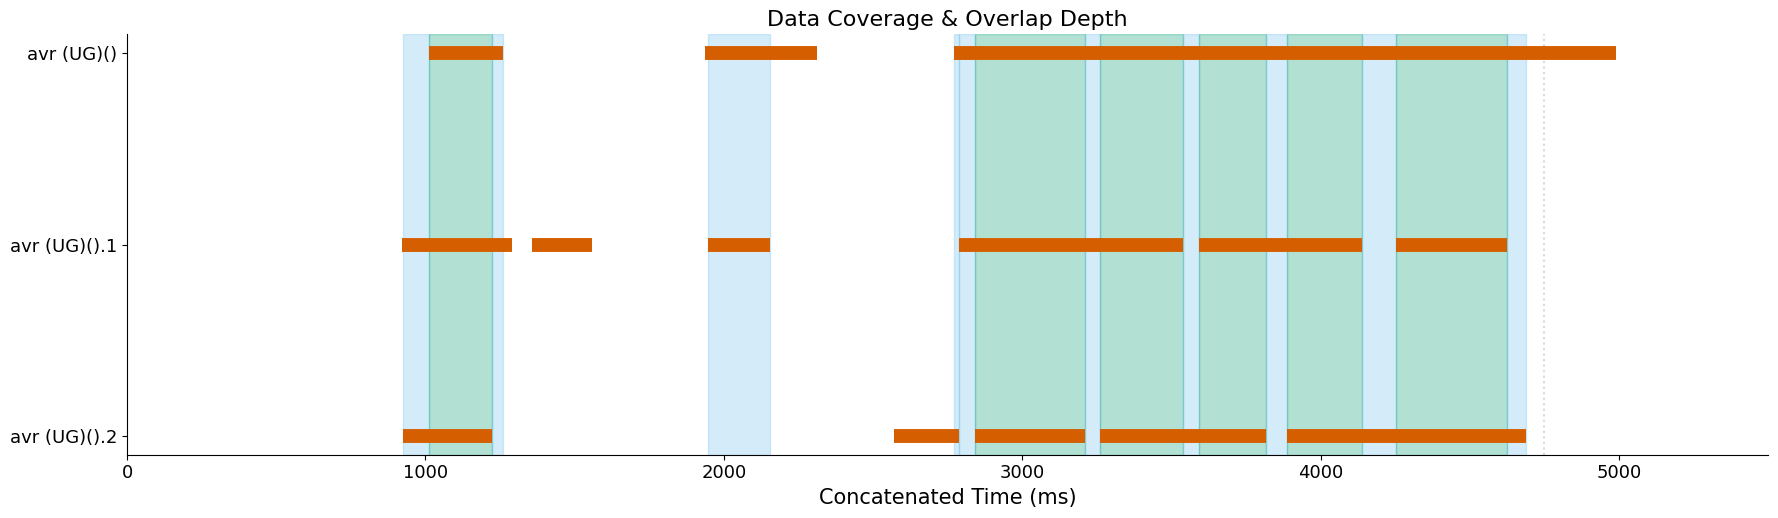


>>> PAIRWISE STATISTICS (with Shuffle Test) <<<
avr (UG)() vs avr (UG)().1: R = 0.677 (Z=124.1, p=0.0010) [***]
avr (UG)() vs avr (UG)().2: R = 0.727 (Z=167.5, p=0.0010) [***]
avr (UG)().1 vs avr (UG)().2: R = 0.612 (Z=353.1, p=0.0010) [***]


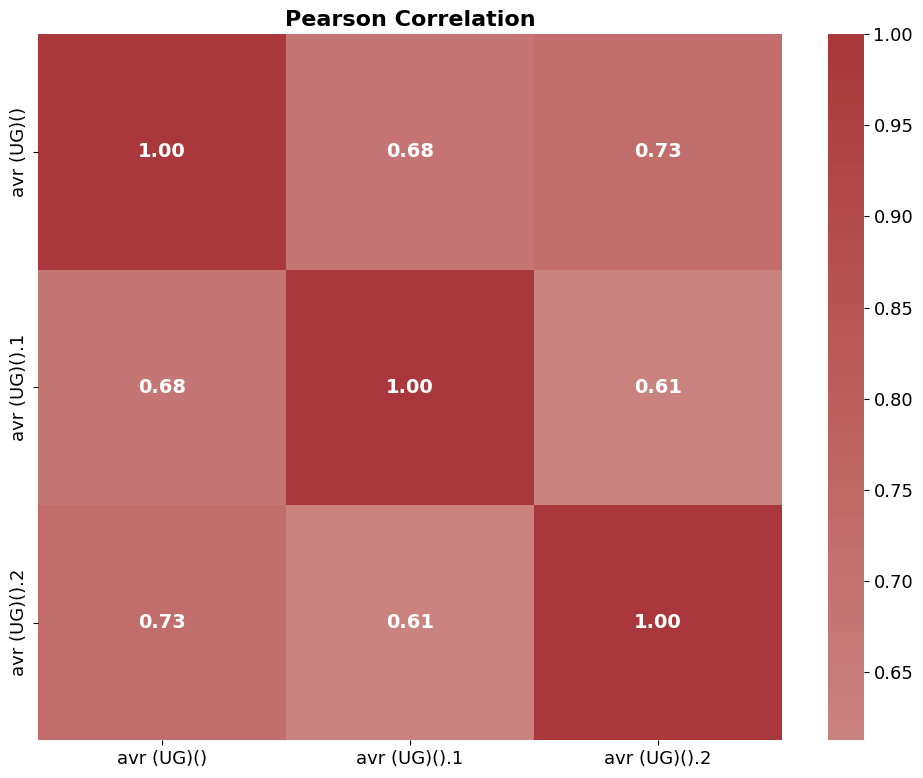


>>> TOP 3 SIGNIFICANT PAIRS


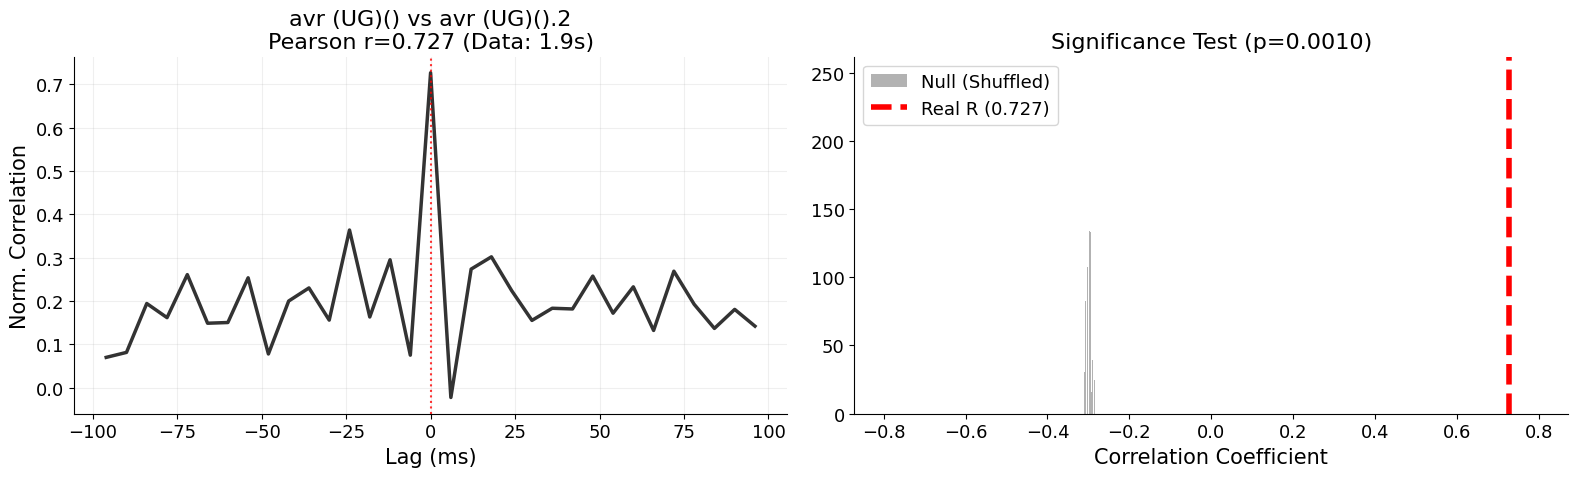

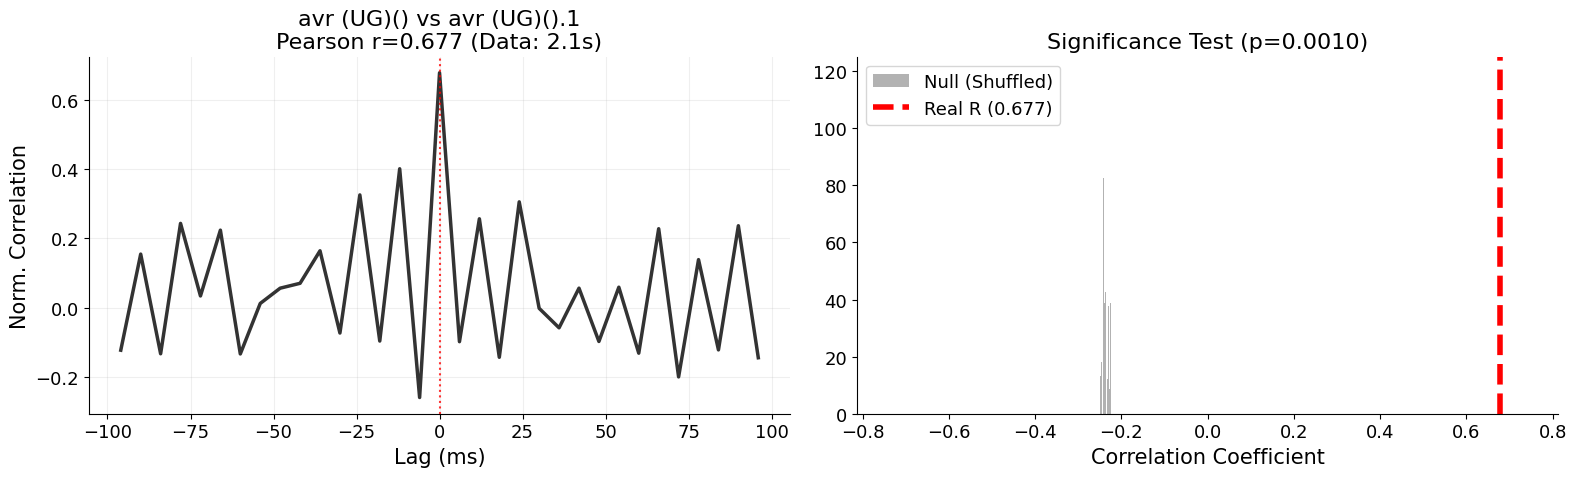

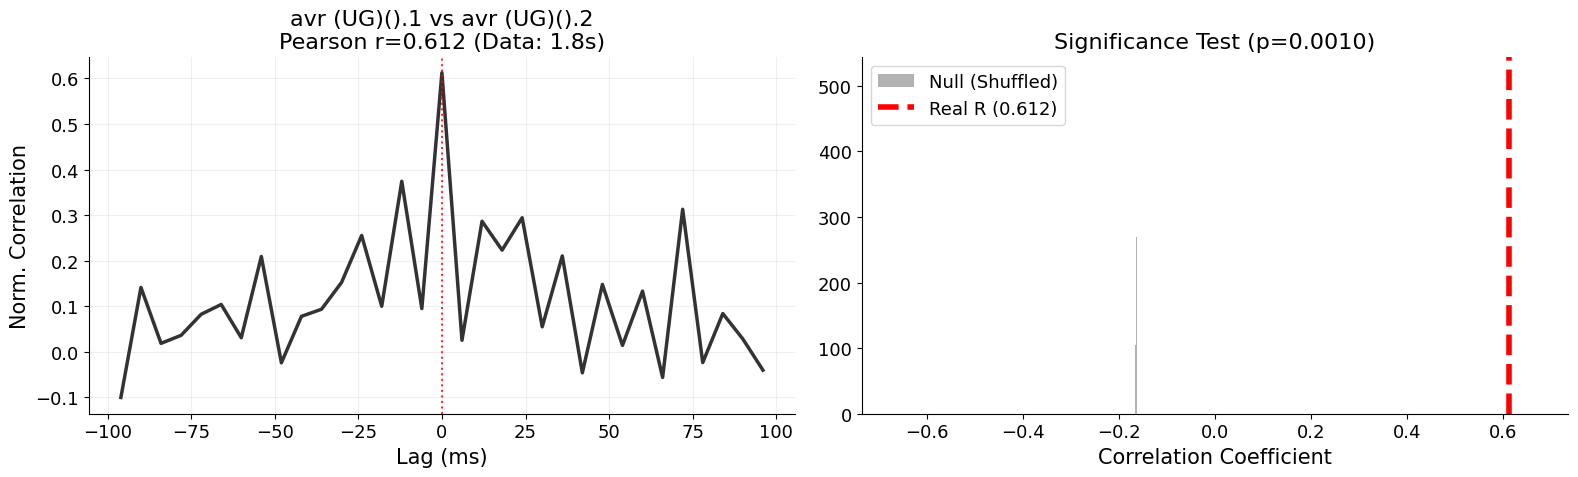

In [6]:
print("\n" + "="*60 + "\n>>> PART C: GRAND TIMELINE, RATE & SIGNIFICANCE\n" + "="*60)

npz_files = glob.glob(os.path.join(INPUT_FOLDER, "*", "*_analyzed.npz"))

if not npz_files:
    print("No files found. Run Block 2 first.")
else:
    first_data = np.load(npz_files[0], allow_pickle=True)
    cell_names = first_data['cell_names']
    n_cells = len(cell_names)
    
    grand_intervals = [[] for _ in range(n_cells)] 
    file_boundaries = []
    pair_data = {} 
    pairs = list(combinations(range(n_cells), 2))
    for p in pairs:
        pair_data[p] = {'spikes_A': [], 'spikes_B': [], 'duration': 0.0}

    cell_stats = {name: {'duration': 0.0, 'spike_count': 0} for name in cell_names}
    current_time_offset = 0.0
    SESSION_GAP_DISPLAY = 500

    print(f"Aggregating {len(npz_files)} sessions...")

    for fpath in npz_files:
        data = np.load(fpath, allow_pickle=True)
        t_vec = data['time_ms']
        rec_dur = t_vec[-1] - t_vec[0]
        valid_start_time = t_vec[0] + IGNORE_START_MS
        
        file_intervals = []
        for i in range(n_cells):
            ss_times = data['spike_times_ss'][i]
            ss_times = ss_times[ss_times > valid_start_time]
            if len(ss_times) > 0:
                ints = get_valid_intervals(ss_times, MAX_ALLOWED_GAP_MS, t_vec[0], t_vec[-1])
                ints = [iv for iv in ints if (iv[1]-iv[0]) >= MIN_SEGMENT_MS]
            else: ints = []
            file_intervals.append(ints)
            for start, end in ints:
                cell_stats[cell_names[i]]['duration'] += (end - start)
                spikes_in_seg = len(ss_times[(ss_times >= start) & (ss_times <= end)])
                cell_stats[cell_names[i]]['spike_count'] += spikes_in_seg
                s_shift = (start - t_vec[0]) + current_time_offset
                e_shift = (end - t_vec[0]) + current_time_offset
                grand_intervals[i].append((s_shift, e_shift))

        for (idx_a, idx_b) in pairs:
            overlap = intersect_intervals(file_intervals[idx_a], file_intervals[idx_b])
            overlap = [ep for ep in overlap if (ep[1]-ep[0]) >= MIN_SEGMENT_MS]
            if len(overlap) > 0:
                for t_s, t_e in overlap:
                    duration = t_e - t_s
                    pair_data[(idx_a, idx_b)]['duration'] += duration
                    times_a = data['spike_times_ss'][idx_a]; times_b = data['spike_times_ss'][idx_b]
                    spikes_a_win = times_a[(times_a >= t_s) & (times_a <= t_e)]
                    spikes_b_win = times_b[(times_b >= t_s) & (times_b <= t_e)]
                    pair_data[(idx_a, idx_b)]['spikes_A'].extend(spikes_a_win - t_s + current_time_offset)
                    pair_data[(idx_a, idx_b)]['spikes_B'].extend(spikes_b_win - t_s + current_time_offset)
        
        file_boundaries.append(current_time_offset + rec_dur)
        current_time_offset += (rec_dur + SESSION_GAP_DISPLAY)
        
    # 2. PLOT TIMELINE
    depth_segments = calculate_coverage_depth(grand_intervals)
    fig, ax = plt.subplots(figsize=(18, 3 + (n_cells * 0.8)))
    for start, end, depth in depth_segments:
        if depth == 2: ax.axvspan(start, end, color='#56B4E9', alpha=0.25, zorder=0)
        elif depth >= 3: ax.axvspan(start, end, color='#009E73', alpha=0.3, zorder=0)
    for bound in file_boundaries: ax.axvline(bound - (SESSION_GAP_DISPLAY/2), color='k', ls=':', alpha=0.15)
    y_ticks = []
    for i in range(n_cells):
        y_pos = n_cells - 1 - i; y_ticks.append(y_pos)
        for start, end in grand_intervals[i]:
             ax.plot([start, end], [y_pos, y_pos], color='#D55E00', lw=10, solid_capstyle='butt', zorder=2)
    ax.set_yticks(y_ticks); ax.set_yticklabels(cell_names)
    ax.set_xlabel("Concatenated Time (ms)"); ax.set_title(f"Data Coverage & Overlap Depth")
    ax.set_xlim(0, current_time_offset)
    plt.tight_layout(); plt.show()

    # 3. COMPUTE STATS & SIGNIFICANCE
    corr_matrix = np.zeros((n_cells, n_cells))
    pval_matrix = np.zeros((n_cells, n_cells))
    results_list = []

    print(f"\n>>> PAIRWISE STATISTICS (with Shuffle Test) <<<")
    
    for (idx_a, idx_b), pdata in pair_data.items():
        dur = pdata['duration']
        spk_a = np.array(pdata['spikes_A'])
        spk_b = np.array(pdata['spikes_B'])
        
        if dur > 500 and len(spk_a) > 10 and len(spk_b) > 10:
            r, lags, xcorr = compute_pair_stats(spk_a, spk_b, CORR_BIN_MS)
            p_val, z_score, shuff_dist = compute_significance_shuffle(spk_a, spk_b, CORR_BIN_MS, dur, r, n_shuffles=1000)
            
            corr_matrix[idx_a, idx_b] = r; corr_matrix[idx_b, idx_a] = r
            pval_matrix[idx_a, idx_b] = p_val; pval_matrix[idx_b, idx_a] = p_val
            
            sig_str = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
            print(f"{cell_names[idx_a]} vs {cell_names[idx_b]}: R = {r:.3f} (Z={z_score:.1f}, p={p_val:.4f}) [{sig_str}]")
            
            results_list.append({'pair': f"{cell_names[idx_a]} vs {cell_names[idx_b]}",
                                 'r': r, 'lags': lags, 'xcorr': xcorr, 'dur': dur, 
                                 'pval': p_val, 'shuff': shuff_dist})
        else:
            print(f"{cell_names[idx_a]} vs {cell_names[idx_b]}: Insufficient Data")
            
    np.fill_diagonal(corr_matrix, 1.0)

    # 4. PLOTS
    if n_cells > 1:
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, 
                    xticklabels=cell_names, yticklabels=cell_names, ax=ax,
                    annot_kws={"size": 14, "weight": "bold"})
        ax.set_title("Pearson Correlation", fontweight='bold')
        plt.tight_layout(); plt.show()

        results_list.sort(key=lambda x: abs(x['r']), reverse=True)
        print(f"\n>>> TOP {DISPLAY_TOP_N_PAIRS} SIGNIFICANT PAIRS")
        
        count = 0
        for res in results_list:
            if count >= DISPLAY_TOP_N_PAIRS: break
            if len(res['lags']) == 0: continue
            count += 1
            
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
            
            # Cross-Correlogram
            ax1.plot(res['lags'], res['xcorr'], color='#333333', lw=2.5)
            ax1.set_title(f"{res['pair']}\nPearson r={res['r']:.3f} (Data: {res['dur']/1000:.1f}s)")
            ax1.axvline(0, color='r', ls=':', alpha=0.8)
            ax1.set_xlabel("Lag (ms)"); ax1.set_ylabel("Norm. Correlation")
            ax1.grid(True, alpha=0.2)
            
            # IMPROVED Shuffle Histogram
            ax2.hist(res['shuff'], bins=30, color='gray', alpha=0.6, density=True, label='Null (Shuffled)')
            ax2.axvline(res['r'], color='red', lw=4, linestyle='--', label=f'Real R ({res["r"]:.3f})')
            
            limit = max(abs(res['r']), np.max(np.abs(res['shuff']))) * 1.2
            ax2.set_xlim(-limit, limit)
            ax2.set_title(f"Significance Test (p={res['pval']:.4f})")
            ax2.set_xlabel("Correlation Coefficient"); ax2.legend()
            
            plt.tight_layout(); plt.show()

In [ ]:
# 1. FONT AND STYLE SETUP
def get_smart_scale_step(data_range):
    steps = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
    target = data_range * 0.18
    return min(steps, key=lambda x: abs(x - target))

def add_smart_scalebar(ax, x_range, y_range):
    x_len = get_smart_scale_step(x_range)
    y_len = get_smart_scale_step(y_range)
    xmin, xmax = ax.get_xlim(); ymin, ymax = ax.get_ylim()
    padding_x = (xmax - xmin) * 0.05; padding_y = (ymax - ymin) * 0.05
    corner_x = xmax - padding_x; corner_y = ymin + padding_y
    
    # Draw Thick L-shape
    ax.plot([corner_x - x_len, corner_x, corner_x], 
            [corner_y, corner_y, corner_y + y_len], 
            color='black', lw=4, clip_on=False, solid_capstyle='butt')
    
    ax.text(corner_x - x_len/2, corner_y - padding_y*0.3, f"{x_len:g} ms", 
            ha='center', va='top', fontsize=14, fontweight='bold')
    ax.text(corner_x + padding_x*0.2, corner_y + y_len/2, f"{y_len:g}% $\Delta F/F$", 
            rotation=90, ha='left', va='center', fontsize=14, fontweight='bold')

def get_complex_spike_duration(trace, peak_idx, fs, search_win_ms=100):
    half_win = int((search_win_ms / 2.0 / 1000.0) * fs)
    start, end = max(0, peak_idx - half_win), min(len(trace), peak_idx + half_win)
    segment = trace[start:end]
    if len(segment) < 10: return None, None
    local_peak_idx = peak_idx - start
    peak_val = segment[local_peak_idx]
    local_base = np.percentile(segment, 15) 
    threshold = local_base + (peak_val - local_base) * 0.20
    above_thresh = np.where(segment >= threshold)[0]
    if len(above_thresh) < 2: return None, None
    split_indices = np.where(np.diff(above_thresh) > 1)[0]
    sub_segments = np.split(above_thresh, split_indices + 1)
    cs_segment = next((seg for seg in sub_segments if local_peak_idx in seg), None)
    if cs_segment is None: return None, None
    return (start + cs_segment[0]) * (1000.0 / fs), (start + cs_segment[-1]) * (1000.0 / fs)

# --- UI LOGIC ---
session_options = [os.path.basename(os.path.dirname(f)) for f in npz_files]
session_select = widgets.Dropdown(options=session_options, description='Session:')
cell_select = widgets.Dropdown(description='Cell:')

def update_cell_options(*args):
    try:
        idx = session_options.index(session_select.value)
        data = np.load(npz_files[idx], allow_pickle=True)
        names = list(data['cell_names'])
        cell_select.options = names
        if names: cell_select.value = names[0]
    except Exception: pass

session_select.observe(update_cell_options, 'value')
update_cell_options()

slider_t = widgets.FloatRangeSlider(min=0, max=5000, value=[2000, 2500], step=10, 
                                    description='Time (ms)', layout={'width': '90%'})
slider_y = widgets.FloatSlider(min=0.1, max=10, value=1.0, description='Y Zoom')
ui = widgets.VBox([widgets.HBox([session_select, cell_select]), slider_t, slider_y])
out = widgets.Output()

def plot_publication_traces_final(change=None):
    if not cell_select.value or not session_select.value: return
    with out:
        out.clear_output(wait=True)
        idx = session_options.index(session_select.value)
        data = np.load(npz_files[idx], allow_pickle=True)
        c_idx = list(data['cell_names']).index(cell_select.value)
        fs = data['fs']; t = data['time_ms']
        mask = (t >= slider_t.value[0]) & (t <= slider_t.value[1])
        
        # 1. BASELINE CORRECTION (Logic matched to Process_Purkinje_Cell)
        raw_full = data['raw_data'][:, c_idx]
        window_samples = int(BASELINE_WINDOW_SEC * fs)
        baseline_full = percentile_filter(raw_full, BASELINE_PERCENTILE, size=max(5, window_samples))
        detrended_full = (baseline_full - raw_full) # Matches NEGATIVE_GOING logic
        df_f_percent = (detrended_full[mask] / np.median(raw_full)) * 100 

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(t[mask], df_f_percent, color='black', lw=1.2, zorder=1)
        
        y_max = np.max(df_f_percent)
        y_ss, y_cs = y_max * 1.15, y_max * 1.35 
        
        # 2. MARKERS
        ss_peaks = data['spike_times_ss'][c_idx]
        v_ss = ss_peaks[(ss_peaks >= slider_t.value[0]) & (ss_peaks <= slider_t.value[1])]
        ax.plot(v_ss, [y_ss] * len(v_ss), '|', color=STYLE['ss'], ms=12, mew=2.5, zorder=2)

        cs_times = data['spike_times_cs'][c_idx]
        cs_idxs = (cs_times / (1000.0/fs)).astype(int)
        in_win = (cs_times >= slider_t.value[0]) & (cs_times <= slider_t.value[1])
        for p_t, p_idx in zip(cs_times[in_win], cs_idxs[in_win]):
            t_s, t_e = get_complex_spike_duration(detrended_full, p_idx, fs)
            if t_s: ax.hlines(y=y_cs, xmin=t_s, xmax=t_e, color=STYLE['cs'], lw=5, zorder=3)

        ax.set_axis_off()
        data_min, data_max = np.min(df_f_percent), y_cs * 1.1
        v_range = (data_max - data_min) / slider_y.value
        ax.set_ylim(data_max - v_range, data_max)
        add_smart_scalebar(ax, (slider_t.value[1] - slider_t.value[0]), v_range)
        ax.set_title(f"Cell: {cell_select.value}", loc='left', fontsize=16, fontweight='bold')
        plt.tight_layout(); plt.show()

slider_t.observe(plot_publication_traces_final, 'value')
slider_y.observe(plot_publication_traces_final, 'value')
session_select.observe(plot_publication_traces_final, 'value')
cell_select.observe(plot_publication_traces_final, 'value')

display(ui, out)
plot_publication_traces_final()

Output()

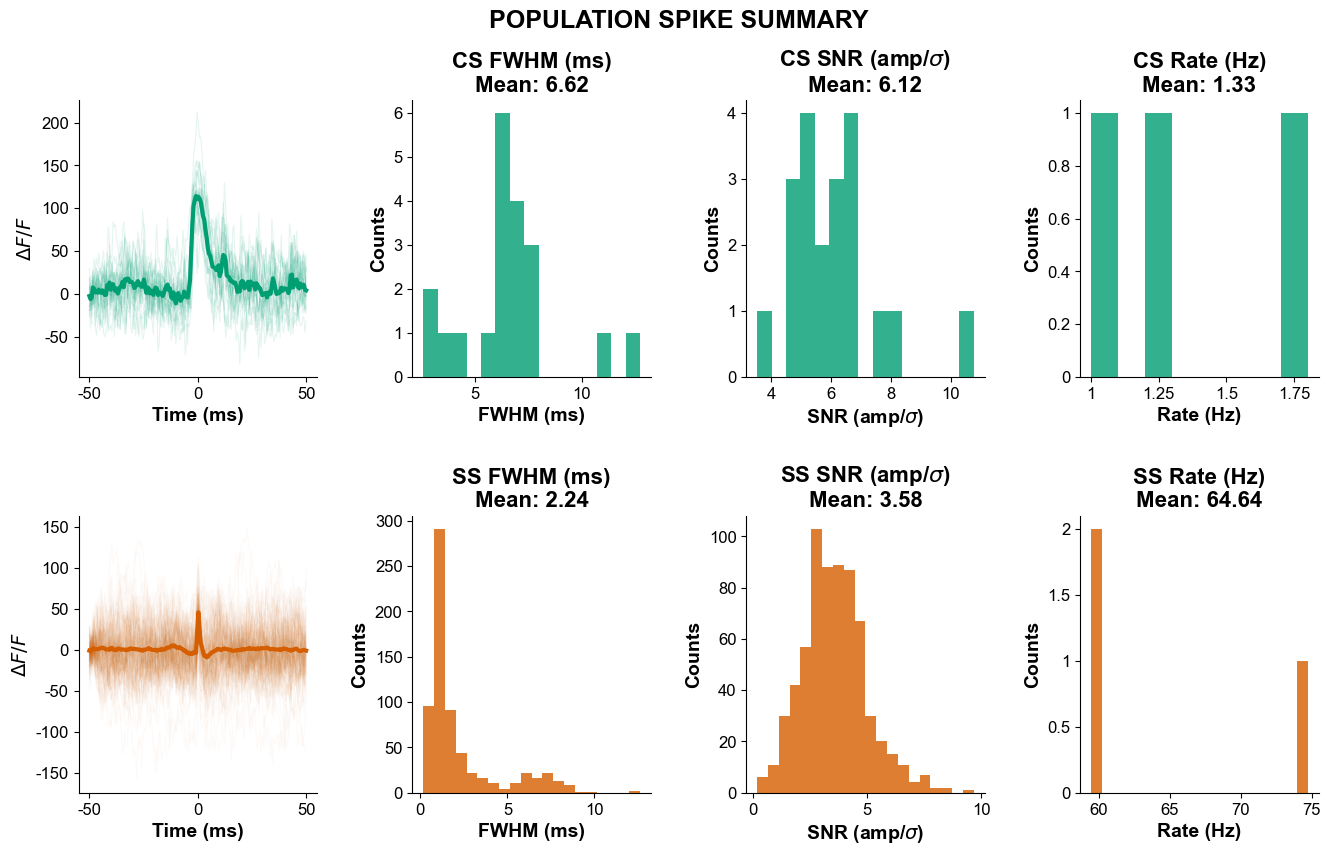

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
import glob

# 1. CORE STYLE AND FORMATTING
def format_pub_axes(ax, ylabel, xlabel="", zap_zero=True):
    # --- FONT SETTINGS: ARIAL ---
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial']
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=14, fontweight='bold')
    ax.tick_params(direction='out', labelsize=12)
    if zap_zero:
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g'))
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%g'))

# 2. POPULATION AGGREGATION AND PLOTTING
def plot_final_population_report_refined():
    all_ss_rates, all_cs_rates = [], []
    all_ss_waves, all_cs_waves = [], []
    ss_fwhm, ss_snr = [], []
    cs_fwhm, cs_snr = [], []

    npz_files = glob.glob(os.path.join(INPUT_FOLDER, "*", "*_analyzed.npz"))
    
    for fpath in npz_files:
        try:
            data = np.load(fpath, allow_pickle=True)
            fs = data['fs']; dt = 1000.0 / fs
            dur_sec = (data['time_ms'][-1] - data['time_ms'][0]) / 1000.0
            hw = int(50 * fs / 1000) 
            
            for i in range(len(data['cell_names'])):
                # --- RATE LOGIC (VALID PERIODS) ---
                ss_times = data['spike_times_ss'][i]
                if len(ss_times) > 2:
                    ss_isis = np.diff(ss_times)
                    # Filter out gaps (invalid periods)
                    valid_ss_isis = ss_isis[ss_isis <= MAX_ALLOWED_GAP_MS]
                    if len(valid_ss_isis) > 0:
                        all_ss_rates.append(1000.0 / np.mean(valid_ss_isis))
                
                cs_times = data['spike_times_cs'][i]
                all_cs_rates.append(len(cs_times) / dur_sec)

                # --- WAVEFORM LOGIC ---
                raw = data['raw_data'][:, i]
                working_trace = raw * -1 if NEGATIVE_GOING else raw
                detrended = detrend_trace(working_trace, fs, BASELINE_WINDOW_SEC, BASELINE_PERCENTILE)
                sigma = data['raw_sigmas'][i]
                
                for s_type, s_times, wave_list, f_list, snr_list in zip(
                    ['SS', 'CS'], [ss_times, cs_times], 
                    [all_ss_waves, all_cs_waves], [ss_fwhm, cs_fwhm], [ss_snr, cs_snr]):
                    
                    idxs = (s_times / dt).astype(int)
                    for idx in idxs:
                        if hw < idx < len(detrended) - hw:
                            wave = detrended[idx-hw : idx+hw]
                            wave_z = wave - np.mean(wave[:5])
                            wave_list.append(wave_z)
                            _, w_int = get_interpolated_wave(wave_z, fs)
                            t_int = np.linspace(-50, 50, len(w_int))
                            amp, fwhm = get_wave_stats(w_int, t_int)
                            if not np.isnan(fwhm):
                                f_list.append(fwhm); snr_list.append(amp / sigma)
        except Exception as e:
            print(f"Skipping {fpath}: {e}")

    # --- PLOTTING ---
    fig = plt.figure(figsize=(16, 9)) 
    gs = fig.add_gridspec(2, 4, hspace=0.5, wspace=0.4)
    
    if not all_ss_waves or not all_cs_waves:
        print("No waveform data found.")
        return

    ss_arr, cs_arr = np.array(all_ss_waves), np.array(all_cs_waves)
    t_plot = np.linspace(-50, 50, ss_arr.shape[1])

    # Row 1: Complex Spike (CS)
    ax_cs_wf = fig.add_subplot(gs[0, 0])
    for w in cs_arr[np.random.choice(len(cs_arr), min(50, len(cs_arr)), replace=False)]:
        ax_cs_wf.plot(t_plot, w, color='#009E73', alpha=0.1, lw=0.8)
    ax_cs_wf.plot(t_plot, np.mean(cs_arr, axis=0), color='#009E73', lw=3)
    format_pub_axes(ax_cs_wf, "$\Delta F/F$", "Time (ms)")
    
    # CS Stats (Units in Title & Label)
    cs_metrics = [
        (cs_fwhm, "CS FWHM (ms)", "FWHM (ms)", 15),
        (cs_snr, "CS SNR (amp/$\sigma$)", "SNR (amp/$\sigma$)", 15),
        (all_cs_rates, "CS Rate (Hz)", "Rate (Hz)", 8) # Reduced bins to close gaps
    ]
    
    for i, (data, title, xlabel, n_bins) in enumerate(cs_metrics):
        ax = fig.add_subplot(gs[0, i+1])
        ax.hist(data, color='#009E73', bins=n_bins, alpha=0.8)
        ax.set_title(f"{title}\nMean: {np.mean(data):.2f}", fontweight='bold')
        format_pub_axes(ax, "Counts", xlabel)

    # Row 2: Simple Spike (SS)
    ax_ss_wf = fig.add_subplot(gs[1, 0])
    for w in ss_arr[np.random.choice(len(ss_arr), min(100, len(ss_arr)), replace=False)]:
        ax_ss_wf.plot(t_plot, w, color='#D55E00', alpha=0.03, lw=0.8)
    ax_ss_wf.plot(t_plot, np.mean(ss_arr, axis=0), color='#D55E00', lw=3)
    format_pub_axes(ax_ss_wf, "$\Delta F/F$", "Time (ms)")
    
    # SS Stats (Units in Title & Label)
    ss_metrics = [
        (ss_fwhm, "SS FWHM (ms)", "FWHM (ms)", 20),
        (ss_snr, "SS SNR (amp/$\sigma$)", "SNR (amp/$\sigma$)", 20),
        (all_ss_rates, "SS Rate (Hz)", "Rate (Hz)", 20)
    ]
    
    for i, (data, title, xlabel, n_bins) in enumerate(ss_metrics):
        ax = fig.add_subplot(gs[1, i+1])
        ax.hist(data, color='#D55E00', bins=n_bins, alpha=0.8)
        ax.set_title(f"{title}\nMean: {np.mean(data):.2f}", fontweight='bold')
        format_pub_axes(ax, "Counts", xlabel)

    plt.suptitle("POPULATION SPIKE SUMMARY", fontweight='bold', fontsize=18, y=0.98)
    plt.tight_layout(); plt.show()

plot_final_population_report_refined()

>>> Binning spikes...
>>> Computing correlations for 9 pairs...


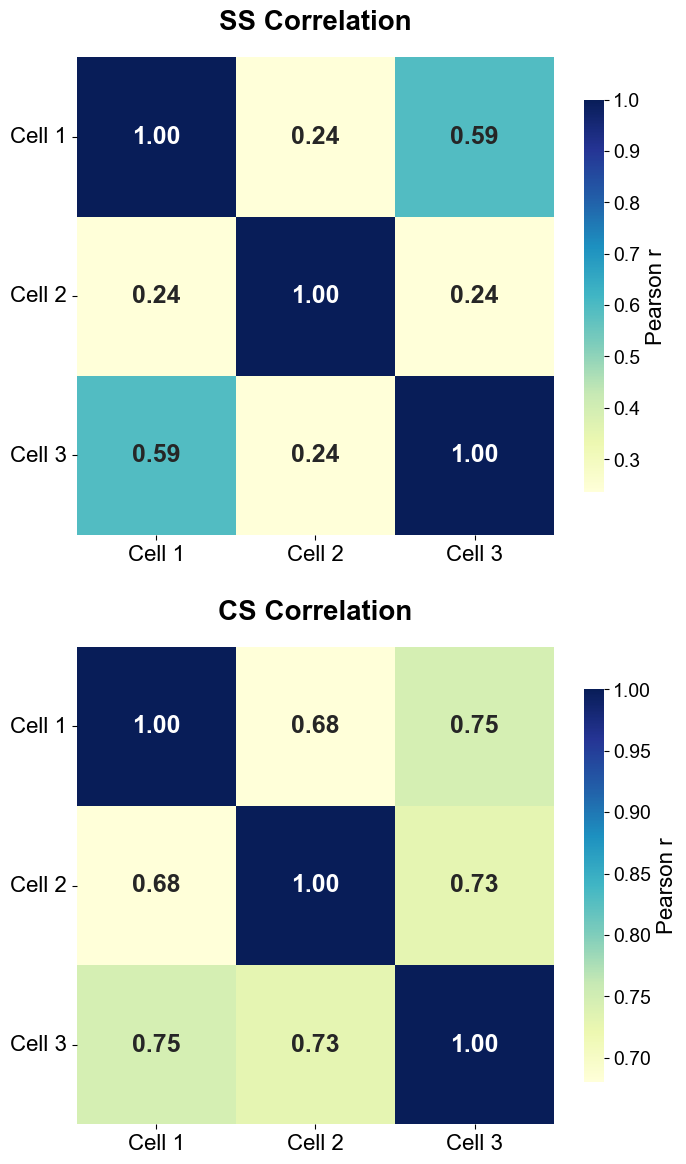

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def get_valid_mask(spikes, duration_s, fs, max_gap_ms=50):
    """Creates a boolean mask for periods where ISIs are below the threshold."""
    mask = np.zeros(int(duration_s * fs) + 1, dtype=bool)
    if len(spikes) < 2: return mask
    
    isis_ms = np.diff(spikes) / fs * 1000.0
    valid_intervals = np.where(isis_ms <= max_gap_ms)[0]
    
    for idx in valid_intervals:
        mask[int(spikes[idx]) : int(spikes[idx+1])] = True
    return mask

def get_binned_rate(spikes_idx, duration_s, fs, bin_ms=50, mask=None):
    """Bins spikes and applies a validity mask (NaN for invalid bins)."""
    bins = np.arange(0, duration_s + bin_ms/1000.0, bin_ms/1000.0)
    counts, _ = np.histogram(spikes_idx / fs, bins=bins)
    
    if mask is not None:
        samples_per_bin = int((bin_ms / 1000.0) * fs)
        masked_counts = []
        for b in range(len(counts)):
            start, end = b * samples_per_bin, (b+1) * samples_per_bin
            if len(mask[start:end]) == 0 or np.mean(mask[start:end]) < 0.5:
                masked_counts.append(np.nan)
            else:
                masked_counts.append(counts[b])
        return np.array(masked_counts)
    return counts

def compute_corr_simple(vec1, vec2):
    """Simple Pearson r calculation handling NaNs."""
    valid = ~np.isnan(vec1) & ~np.isnan(vec2)
    v1, v2 = vec1[valid], vec2[valid]
    if len(v1) < 10: return 0.0
    return np.corrcoef(v1, v2)[0, 1]

def plot_final_correlation_report_vertical_clean():
    if not 'last_data_package' in globals(): return
    pkg = last_data_package; n = len(pkg['cells'])
    dur = pkg['time'][-1] - pkg['time'][0]; fs = pkg['fs']
    
    # Update Cell Labels
    cell_labels = [f"Cell {i+1}" for i in range(n)]
    
    ss_matrix = np.zeros((n,n))
    cs_matrix = np.zeros((n,n))

    ss_vectors, cs_vectors = [], []
    print(">>> Binning spikes...")
    for i in range(n):
        ss_idx = pkg['results'][i]['ss_peaks']
        v_mask = get_valid_mask(ss_idx, dur, fs, MAX_ALLOWED_GAP_MS)
        ss_vectors.append(get_binned_rate(ss_idx, dur, fs, bin_ms=50, mask=v_mask))
        
        cs_idx = pkg['results'][i]['cs_peaks']
        cs_vectors.append(get_binned_rate(cs_idx, dur, fs, bin_ms=100))

    print(f">>> Computing correlations for {n*n} pairs...")
    for i in range(n):
        for j in range(n):
            ss_matrix[i,j] = compute_corr_simple(ss_vectors[i], ss_vectors[j])
            cs_matrix[i,j] = compute_corr_simple(cs_vectors[i], cs_vectors[j])

    # --- PLOTTING ---
    # Global Font Scale Update for this block
    plt.rcParams.update({'font.size': 14, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14})

    # Vertical Layout (2 Rows, 1 Column)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 12)) 
    
    for ax, mat, title in zip([ax1, ax2], [ss_matrix, cs_matrix], 
                                     ["SS Correlation", "CS Correlation"]):
        
        # Heatmap without significance stars
        sns.heatmap(mat, annot=True, fmt=".2f", cmap='YlGnBu', ax=ax, square=True,
                    xticklabels=cell_labels, yticklabels=cell_labels, 
                    annot_kws={"size": 18, "fontweight": "bold"}, 
                    cbar_kws={'label': 'Pearson r', "shrink": 0.8})
        
        # Larger Title and padded for clean look
        ax.set_title(title, fontweight='bold', fontsize=20, pad=20)
        ax.tick_params(axis='both', which='major', labelsize=16, rotation=0)

    plt.tight_layout()
    plt.show()

plot_final_correlation_report_vertical_clean()

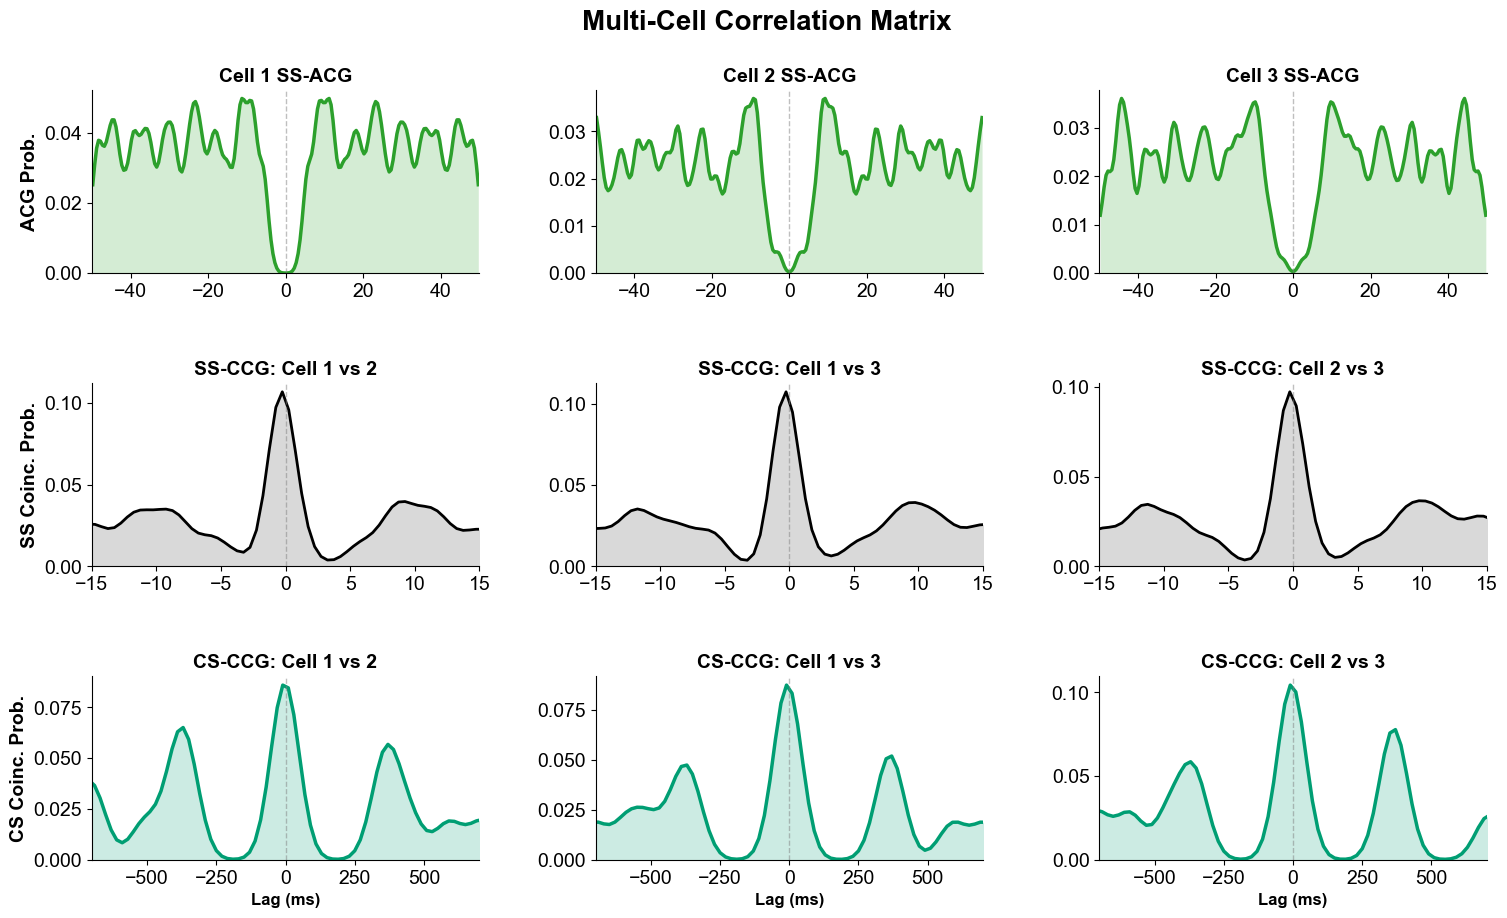

In [10]:
from scipy.ndimage import gaussian_filter1d
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np

# --- 1. COMPUTATION FUNCTION ---
def compute_prob_ccg(spikes1, spikes2, bin_ms=1.0, window_ms=50, sigma=1.5, is_acg=False):
    """
    Computes smoothed Coincidence Probability.
    Y-axis = Probability of a spike in Target given a spike in Reference at lag t.
    """
    if len(spikes1) < 2 or len(spikes2) < 2: return None, None
    
    bin_s = bin_ms / 1000.0
    win_s = window_ms / 1000.0
    # Create bins for histogram
    bins = np.arange(-win_s, win_s + bin_s, bin_s)
    
    # Calculate Differences
    diffs = []
    for r in spikes1:
        # Vectorized search for neighbors within window
        close = spikes2[(spikes2 >= r - win_s) & (spikes2 <= r + win_s)]
        diffs.extend(close - r)
        
    if len(diffs) == 0: return bins[:-1]*1000, np.zeros(len(bins)-1)

    counts, edges = np.histogram(diffs, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2 * 1000
    
    if is_acg:
        # Mask center 0-lag for ACG to remove the self-correlation peak
        # Mask roughly +/- 1.5ms to be safe
        mask = (centers > -1.5) & (centers < 1.5)
        counts[mask] = 0

    # Normalization: Probability per bin
    # "Given a spike in Cell 1, what is the prob Cell 2 fires at lag t?"
    prob = counts / len(spikes1)

    # Smoothing
    smooth_prob = gaussian_filter1d(prob, sigma=sigma, mode='nearest')
    
    return centers, smooth_prob

# --- 2. PLOTTING FUNCTION ---
def plot_poster_matrix_rows():
    if not 'last_data_package' in globals(): return
    pkg = last_data_package
    cells = pkg['cells']
    n_cells = min(len(cells), 3) # Limit to first 3 cells
    
    if n_cells < 2: print("Need at least 2 cells."); return

    # Setup 3x3 Grid
    fig, axes = plt.subplots(3, 3, figsize=(18, 10))
    plt.subplots_adjust(hspace=0.6, wspace=0.3)
    
    # Define Pairs for Columns: (1-2), (1-3), (2-3)
    # If only 2 cells exist, we just plot the first pair.
    possible_pairs = list(combinations(range(n_cells), 2))
    
    # --- ROW 1: ACG (Cell 1, Cell 2, Cell 3) ---
    for i in range(3):
        ax = axes[0, i]
        if i < n_cells:
            c_name = f"Cell {i+1}"
            spikes = pkg['time'][pkg['results'][i]['ss_peaks']] / 1000.0
            
            # CHANGED: window_ms=50 for +/- 50ms range
            t, p = compute_prob_ccg(spikes, spikes, bin_ms=0.5, window_ms=50, sigma=2.0, is_acg=True)
            
            if t is not None:
                ax.plot(t, p, color='#2ca02c', lw=2.5) # Dark Green
                ax.fill_between(t, 0, p, color='#2ca02c', alpha=0.2, lw=0) # Light Green Fill
                ax.set_title(f"{c_name} SS-ACG", fontweight='bold', fontsize=14)
                
                # CHANGED: Explicitly set X-limits to match new window
                ax.set_xlim(-50, 50) 
                ax.set_ylim(bottom=0)
        else:
            ax.axis('off') # Hide empty plot if < 3 cells

    # --- ROW 2: SS-CCG (Pairs) ---
    for i in range(3):
        ax = axes[1, i]
        if i < len(possible_pairs):
            idx1, idx2 = possible_pairs[i]
            pair_name = f"Cell {idx1+1} vs {idx2+1}"
            ss1 = pkg['time'][pkg['results'][idx1]['ss_peaks']] / 1000.0
            ss2 = pkg['time'][pkg['results'][idx2]['ss_peaks']] / 1000.0
            
            # Keeping CCG narrower for detail, or change to 50 if desired
            t, p = compute_prob_ccg(ss1, ss2, bin_ms=0.5, window_ms=20, sigma=2.0)
            
            if t is not None:
                ax.plot(t, p, color='black', lw=2.0)
                ax.fill_between(t, 0, p, color='black', alpha=0.15, lw=0)
                ax.set_title(f"SS-CCG: {pair_name}", fontweight='bold', fontsize=14)
                ax.set_xlim(-15, 15)
                ax.set_ylim(bottom=0)
        else:
            ax.axis('off')

    # --- ROW 3: CS-CCG (Pairs) ---
    for i in range(3):
        ax = axes[2, i]
        if i < len(possible_pairs):
            idx1, idx2 = possible_pairs[i]
            pair_name = f"Cell {idx1+1} vs {idx2+1}"
            cs1 = pkg['time'][pkg['results'][idx1]['cs_peaks']] / 1000.0
            cs2 = pkg['time'][pkg['results'][idx2]['cs_peaks']] / 1000.0
            
            # WIDER BINS & WINDOW for CS (slow events)
            t, p = compute_prob_ccg(cs1, cs2, bin_ms=20.0, window_ms=1000, sigma=2.5)
            
            if t is not None:
                ax.plot(t, p, color=STYLE['cs'], lw=2.5)
                ax.fill_between(t, 0, p, color=STYLE['cs'], alpha=0.2, lw=0)
                ax.set_title(f"CS-CCG: {pair_name}", fontweight='bold', fontsize=14)
                ax.set_xlim(-700, 700)
                ax.set_ylim(bottom=0)
        else:
            ax.axis('off')

    # --- ROW LABELS & FORMATTING ---
    axes[0, 0].set_ylabel("ACG Prob.", fontweight='bold', fontsize=14)
    axes[1, 0].set_ylabel("SS Coinc. Prob.", fontweight='bold', fontsize=14)
    axes[2, 0].set_ylabel("CS Coinc. Prob.", fontweight='bold', fontsize=14)

    for ax in axes.flatten():
        if ax.has_data():
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.axvline(0, color='gray', ls='--', lw=1, alpha=0.5)
            # Only bottom row gets X-label
            if ax in axes[2, :]:
                ax.set_xlabel("Lag (ms)", fontsize=12, fontweight='bold')

    plt.suptitle("Multi-Cell Correlation Matrix", fontweight='bold', fontsize=20, y=0.96)
    plt.show()

if 'last_data_package' in globals():
    plot_poster_matrix_rows()
else:
    print("Please run Block 2 first to load data.")

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.ndimage import percentile_filter

# --- 1. DEFINE WIDGETS (Self-Contained) ---
if 'npz_files' in globals():
    file_options = [os.path.basename(os.path.dirname(f)) for f in npz_files]
    w_session = widgets.Dropdown(options=file_options, description='Session:')
    w_cell = widgets.Dropdown(description='Cell:')
    w_time = widgets.FloatRangeSlider(min=0, max=5000, value=[2000, 2500], step=10, description='Time (ms)', layout={'width': '80%'})
    w_zoom = widgets.FloatSlider(min=0.1, max=5.0, value=1.0, step=0.1, description='Gain')
    w_out = widgets.Output()
    
    w_ui = widgets.VBox([
        widgets.HBox([w_session, w_cell, w_zoom]),
        w_time
    ])
else:
    print("Please run Block 2 to load data first.")

# --- 2. PLOTTING FUNCTIONS ---

def add_fixed_scalebar(ax, x_len_ms, y_len_data, y_label_text):
    """Adds a scale bar with fixed dimensions and custom label."""
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    
    # Place in bottom right corner
    corner_x = xmax
    corner_y = ymin + (ymax - ymin) * 0.05
    
    # Draw L-shape (Thick Black)
    ax.plot([corner_x, corner_x], [corner_y, corner_y + y_len_data], color='black', lw=4, clip_on=False)
    ax.plot([corner_x - x_len_ms, corner_x], [corner_y, corner_y], color='black', lw=4, clip_on=False)
    
    # Labels
    ax.text(corner_x - x_len_ms/2, corner_y - (ymax-ymin)*0.02, f"{x_len_ms} ms", 
            ha='center', va='top', fontsize=14, fontweight='bold')
    ax.text(corner_x + (xmax-xmin)*0.01, corner_y + y_len_data/2, y_label_text, 
            rotation=90, ha='left', va='center', fontsize=14, fontweight='bold')

def plot_methods_stacked_final(change=None):
    if 'npz_files' not in globals() or not w_session.options: return

    # Ensure valid selection
    current_files = [os.path.basename(os.path.dirname(f)) for f in npz_files]
    if w_session.value not in current_files:
        w_session.options = current_files
        w_session.value = current_files[0]

    with w_out:
        w_out.clear_output(wait=True)
        try:
            idx = current_files.index(w_session.value)
            data = np.load(npz_files[idx], allow_pickle=True)
            
            # Update Cell List
            cell_list = list(data['cell_names'])
            w_cell.options = cell_list
            if w_cell.value not in cell_list:
                if cell_list: w_cell.value = cell_list[0]
                else: return 
            
            c_idx = cell_list.index(w_cell.value)
            fs = data['fs']; t_full = data['time_ms']
            raw_full = data['raw_data'][:, c_idx]
        except Exception as e:
            print(f"Data Load Error: {e}"); return
        
        # --- PROCESSING ---
        win = int(BASELINE_WINDOW_SEC * fs)
        base = percentile_filter(raw_full, BASELINE_PERCENTILE, size=max(5, win))
        global_base = np.median(base)
        
        # Normalize all to % dF/F
        raw_norm = (raw_full / global_base - 1) * 100
        base_norm = (base / global_base - 1) * 100
        
        if NEGATIVE_GOING:
            result_dff = ((base - raw_full) / base) * 100
        else:
            result_dff = ((raw_full - base) / base) * 100
            
        cs_stream_raw = data['cs_traces'][:, c_idx]
        ss_stream_raw = data['ss_traces'][:, c_idx]
        
        cs_dff = (cs_stream_raw / global_base) * 100
        ss_dff = (ss_stream_raw / global_base) * 100
        
        # Thresholds
        sigma_cs_raw = estimate_noise_mad(cs_stream_raw)
        sigma_ss_raw = estimate_noise_mad(ss_stream_raw[ss_stream_raw!=0])
        th_cs_dff = (CS_THRESHOLD_SIGMA * sigma_cs_raw / global_base) * 100
        th_ss_dff = (SS_THRESHOLD_SIGMA * sigma_ss_raw / global_base) * 100

        # --- SLICING ---
        t_min, t_max = w_time.value
        mask = (t_full >= t_min) & (t_full <= t_max)
        t = t_full[mask]
        if len(t) < 10: return

        # --- STACKING & ZOOM ---
        vis_range = np.percentile(result_dff[mask], 99) - np.percentile(result_dff[mask], 1)
        if vis_range == 0: vis_range = 1
        
        # CHANGED: Increased multiplier to 7.0 to prevent overlap
        spacing = vis_range * 7.0 
        
        gain = w_zoom.value
        
        offset_base = spacing * 3
        offset_cs = spacing * 2
        offset_ss = spacing * 1
        offset_res = 0
        
        # --- PLOTTING ---
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # 1. Baseline Correction
        ax.plot(t, (raw_norm[mask] * gain) + offset_base, color='#999999', lw=1)
        ax.plot(t, (base_norm[mask] * gain) + offset_base, color=STYLE['drift'], ls='--', lw=2.5)
        ax.text(t[0], offset_base + spacing*0.4, "Baseline Correction", fontweight='bold', fontsize=16)
        
        # 2. CS Stream
        ax.plot(t, (cs_dff[mask] * gain) + offset_cs, color=STYLE['cs'], lw=1.5)
        ax.axhline((th_cs_dff * gain) + offset_cs, color=STYLE['cs_th'], ls='--', alpha=0.8)
        ax.text(t[0], offset_cs + spacing*0.4, "Band-pass filtering + spike detection", fontweight='bold', fontsize=16)
        
        # 3. SS Stream
        ax.plot(t, (ss_dff[mask] * gain) + offset_ss, color=STYLE['ss'], lw=1.2)
        ax.axhline((th_ss_dff * gain) + offset_ss, color=STYLE['ss_th'], ls='--', alpha=0.8)
        
        # 4. Result
        clean = result_dff[mask]
        ax.plot(t, (clean * gain) + offset_res, 'k', lw=1.5)
        ax.text(t[0], offset_res + spacing*0.4, "Result", fontweight='bold', fontsize=16)
        
        # --- TICKS ---
        visual_top = np.max(clean * gain) + offset_res
        
        # CS Ticks
        cs_indices = data['spike_times_cs'][c_idx] / (1000.0/fs)
        cs_indices = cs_indices.astype(int)
        start_samp = int(t_min / (1000.0/fs))
        end_samp = int(t_max / (1000.0/fs))
        
        for p_idx in cs_indices:
            if p_idx >= start_samp and p_idx <= end_samp:
                t_s_ms, t_e_ms = get_complex_spike_duration(raw_full, p_idx, fs)
                if t_s_ms is None: t_s_ms, t_e_ms = t_full[p_idx]-2, t_full[p_idx]+2
                ax.hlines(y=visual_top + vis_range*0.3, xmin=t_s_ms, xmax=t_e_ms, color=STYLE['cs'], lw=6)

        # SS Ticks (Modified Style)
        ss_local = data['spike_times_ss'][c_idx]
        ss_local = ss_local[(ss_local >= t_min) & (ss_local <= t_max)]
        if len(ss_local) > 0:
            # Elevation: 0.2 (higher), Size: 7 (smaller)
            ax.plot(ss_local, [visual_top + vis_range*0.2] * len(ss_local), '|', color=STYLE['ss'], ms=7, mew=2)

        # Scale Bar
        add_fixed_scalebar(ax, 30, 10 * gain, "0.1 dF/F")

        ax.axis('off')
        plt.tight_layout()
        plt.show()

# --- 3. DISPLAY ---
if 'npz_files' in globals():
    w_session.observe(lambda c: plot_methods_stacked_final(), 'value')
    w_cell.observe(lambda c: plot_methods_stacked_final(), 'value')
    w_time.observe(lambda c: plot_methods_stacked_final(), 'value')
    w_zoom.observe(lambda c: plot_methods_stacked_final(), 'value')
    
    display(w_ui, w_out)
    plot_methods_stacked_final()

Output()

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.ndimage import percentile_filter

# --- 1. HELPER FUNCTIONS ---

def add_fixed_scalebar(ax, x_len_ms, y_len_data, y_label_text):
    """Adds a scale bar with fixed dimensions."""
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    
    # Place scale bar inside the bottom-right
    corner_x = xmax
    corner_y = ymin + (ymax - ymin) * 0.1
    
    # Draw L-shape
    ax.plot([corner_x, corner_x], [corner_y, corner_y + y_len_data], color='black', lw=4, clip_on=False)
    ax.plot([corner_x - x_len_ms, corner_x], [corner_y, corner_y], color='black', lw=4, clip_on=False)
    
    # Labels
    ax.text(corner_x - x_len_ms/2, corner_y - (ymax-ymin)*0.05, f"{x_len_ms} ms", 
            ha='center', va='top', fontsize=14, fontweight='bold')
    ax.text(corner_x + (xmax-xmin)*0.01, corner_y + y_len_data/2, y_label_text, 
            rotation=90, ha='left', va='center', fontsize=14, fontweight='bold')

def get_valid_intervals_local(spike_times, t_start, t_end, max_gap_ms=50):
    local_spikes = spike_times[(spike_times >= t_start) & (spike_times <= t_end)]
    if len(local_spikes) < 2: return []
    isis = np.diff(local_spikes)
    gap_indices = np.where(isis > max_gap_ms)[0]
    intervals = []
    current_start = local_spikes[0]
    for gap_idx in gap_indices:
        current_end = local_spikes[gap_idx]
        intervals.append((current_start, current_end))
        current_start = local_spikes[gap_idx + 1]
    intervals.append((current_start, local_spikes[-1]))
    return intervals

def compute_common_period(intervals_list, min_overlap_count=2):
    if not intervals_list: return []
    
    events = []
    for cell_ints in intervals_list:
        for s, e in cell_ints:
            events.append((s, 1))
            events.append((e, -1))
    
    events.sort(key=lambda x: x[0])
    
    result = []
    current_overlap = 0
    prev_time = events[0][0]
    start_capture = None
    
    for t, change in events:
        if t > prev_time:
            if current_overlap >= min_overlap_count:
                if start_capture is None: start_capture = prev_time
            else:
                if start_capture is not None:
                    result.append((start_capture, prev_time))
                    start_capture = None
        current_overlap += change
        prev_time = t
        
    if start_capture is not None:
        result.append((start_capture, prev_time))
        
    return result

# --- 2. MAIN PLOTTING FUNCTION ---

def plot_multicell_validity_standalone(change=None):
    if not w_session_mc.value: return

    with w_out_mc:
        w_out_mc.clear_output(wait=True)
        try:
            idx = session_options.index(w_session_mc.value)
            data = np.load(npz_files[idx], allow_pickle=True)
            cell_names = list(data['cell_names'])
            display_indices = [0, 1, 2] if len(cell_names) >= 3 else list(range(len(cell_names)))
            fs = data['fs']; t_full = data['time_ms']
        except Exception as e:
            print(f"Data Load Error: {e}"); return

        t_min, t_max = w_time_mc.value
        mask = (t_full >= t_min) & (t_full <= t_max)
        t = t_full[mask]
        if len(t) < 10: return

        # Plotting
        fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1, 0.4]})
        # CHANGED: Increased hspace from 0.15 to 0.5 to prevent overlap
        plt.subplots_adjust(hspace=0.5) 
        
        valid_intervals_all = []
        gain = w_zoom_mc.value

        # Cells (Rows 0-2)
        for i, ax in enumerate(axes[:3]):
            if i < len(display_indices):
                c_idx = display_indices[i]
                
                raw_full = data['raw_data'][:, c_idx]
                win = int(BASELINE_WINDOW_SEC * fs)
                base = percentile_filter(raw_full, BASELINE_PERCENTILE, size=max(5, win))
                
                if NEGATIVE_GOING:
                    dff = ((base - raw_full) / base) * 100
                else:
                    dff = ((raw_full - base) / base) * 100
                
                trace_segment = dff[mask]
                ax.plot(t, trace_segment * gain, 'k', lw=1.2)
                
                # Label moved outside
                ax.text(-0.02, 0.5, f"Cell {i+1}", transform=ax.transAxes, 
                        fontsize=16, fontweight='bold', va='center', ha='right', color='#333333')
                
                y_max = np.max(trace_segment * gain)
                
                # CS Markers
                cs_all = data['spike_times_cs'][c_idx]
                cs_indices = cs_all / (1000.0/fs)
                cs_indices = cs_indices.astype(int)
                start_s = int(t_min/(1000.0/fs)); end_s = int(t_max/(1000.0/fs))
                
                for p_idx in cs_indices:
                    if p_idx >= start_s and p_idx <= end_s:
                        t_s, t_e = get_complex_spike_duration(raw_full if NEGATIVE_GOING else raw_full*-1, p_idx, fs)
                        if t_s is None: t_s, t_e = t_full[p_idx]-2, t_full[p_idx]+2
                        ax.hlines(y=y_max*1.2, xmin=t_s, xmax=t_e, color=STYLE['cs'], lw=5)

                # SS Markers - MODIFIED FOR CONSISTENCY
                ss_all = data['spike_times_ss'][c_idx]
                ss_local = ss_all[(ss_all >= t_min) & (ss_all <= t_max)]
                # Elevate by 20% (1.2) instead of 5% to avoid touching trace
                ax.plot(ss_local, [y_max*1.2]*len(ss_local), '|', color=STYLE['ss'], ms=7, mew=2)
                
                valid_intervals_all.append(get_valid_intervals_local(ss_all, t_min, t_max))
                ax.set_ylim(-np.max(np.abs(trace_segment*gain)), np.max(np.abs(trace_segment*gain))*1.5)
            else:
                ax.text(0.5, 0.5, "No Cell", ha='center')
            
            ax.axis('off')

        # Scale Bar: 30 ms / 0.1 dF/F
        add_fixed_scalebar(axes[2], 30, 10 * gain, "0.1 dF/F")

        # Validity Row
        ax_val = axes[3]
        ax_val.set_ylim(-0.5, len(display_indices)+0.5) 
        ax_val.axis('off')
        
        for i, intervals in enumerate(valid_intervals_all):
            y_pos = len(display_indices) - i
            for v_start, v_end in intervals:
                ax_val.hlines(y=y_pos, xmin=v_start, xmax=v_end, color=STYLE['ss'], lw=8, alpha=0.5)
            # Label for valid bars
            ax_val.text(t_min, y_pos, f"Cell {i+1} Valid", fontsize=12, va='center', ha='right', fontweight='bold')

        # Common Overlap
        if len(valid_intervals_all) > 1:
            overlaps = compute_common_period(valid_intervals_all, min_overlap_count=2)
            for o_start, o_end in overlaps:
                ax_val.hlines(y=0, xmin=o_start, xmax=o_end, color='#0072B2', lw=12)
            ax_val.text(t_min, 0, "Common (≥2)", fontsize=12, va='center', ha='right', fontweight='bold', color='#0072B2')

        plt.show()

# --- 3. UI DEFINITION ---

if 'npz_files' in globals():
    session_options = [os.path.basename(os.path.dirname(f)) for f in npz_files]
    w_session_mc = widgets.Dropdown(options=session_options, description='Session:')
    w_time_mc = widgets.FloatRangeSlider(min=0, max=5000, value=[2000, 2500], step=10, description='Time (ms)', layout={'width': '80%'})
    w_zoom_mc = widgets.FloatSlider(min=0.1, max=5.0, value=1.0, step=0.1, description='Gain')
    w_out_mc = widgets.Output()

    w_session_mc.observe(lambda c: plot_multicell_validity_standalone(), 'value')
    w_time_mc.observe(lambda c: plot_multicell_validity_standalone(), 'value')
    w_zoom_mc.observe(lambda c: plot_multicell_validity_standalone(), 'value')

    display(widgets.VBox([w_session_mc, w_time_mc, w_zoom_mc]), w_out_mc)
    plot_multicell_validity_standalone()
else:
    print("Please run Block 2 to load data first.")

Output()

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

# --- 1. COMPUTATION FUNCTIONS ---

def compute_cs_ss_ccg(cs_times, ss_times, window_ms=50, bin_ms=1.0):
    """
    Computes the cross-correlogram of SS relative to CS times.
    Returns bin centers and counts.
    """
    if len(cs_times) == 0 or len(ss_times) == 0:
        return None, None
        
    # Define bins
    bins = np.arange(-window_ms, window_ms + bin_ms, bin_ms)
    
    # Accumulate differences
    # (For every CS, find SS in window)
    all_diffs = []
    
    # Optimization: iterate over CS (usually fewer) and search SS
    # Assuming times are sorted
    for cs_t in cs_times:
        # Find SS within window range
        t_start = cs_t - window_ms
        t_end = cs_t + window_ms
        
        # Search sorted array
        idx_start = np.searchsorted(ss_times, t_start)
        idx_end = np.searchsorted(ss_times, t_end)
        
        local_ss = ss_times[idx_start:idx_end]
        diffs = local_ss - cs_t
        all_diffs.extend(diffs)
        
    if not all_diffs:
        return bins[:-1] + bin_ms/2, np.zeros(len(bins)-1)
        
    counts, _ = np.histogram(all_diffs, bins=bins)
    centers = bins[:-1] + bin_ms/2
    
    return centers, counts

# --- 2. PLOTTING & STYLING ---

def style_ccg_plot(ax, title):
    """Applies the consistent Arial/Bold styling."""
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial']
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Time from CS (ms)", fontsize=11, fontweight='bold')
    ax.set_ylabel("SS Counts", fontsize=11, fontweight='bold')
    ax.axvline(0, color='k', linestyle='--', alpha=0.5, lw=1)
    ax.tick_params(labelsize=10)

def run_pause_analysis(change=None):
    if not w_sess_pause.value: return
    
    # Load Data
    try:
        idx = session_opts_pause.index(w_sess_pause.value)
        data = np.load(npz_files[idx], allow_pickle=True)
        cell_names = data['cell_names']
        fs = data['fs']
    except Exception as e:
        with w_out_pause: 
            print(f"Error loading: {e}")
        return

    # Setup Plot Grid
    n_cells = len(cell_names)
    cols = 3
    rows = int(np.ceil(n_cells / cols))
    
    with w_out_pause:
        w_out_pause.clear_output(wait=True)
        
        fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
        plt.subplots_adjust(hspace=0.4, wspace=0.3)
        
        # Flatten axes for easy iteration
        if n_cells == 1: axes = [axes] 
        else: axes = axes.flatten()
        
        for i, ax in enumerate(axes):
            if i < n_cells:
                c_name = cell_names[i]
                
                # Get Times
                cs_t = data['spike_times_cs'][i]
                ss_t = data['spike_times_ss'][i]
                
                # Compute CCG
                # Window: +/- 50ms to see pre-CS activity and post-CS pause
                lag, counts = compute_cs_ss_ccg(cs_t, ss_t, window_ms=50, bin_ms=1.0)
                
                if lag is not None:
                    # Plot Histogram
                    # Color: SS Orange (#D55E00)
                    ax.bar(lag, counts, width=1.0, color='#D55E00', align='center', alpha=0.9)
                    
                    # Highlight the expected pause region (0 to 20ms)
                    # We shade it lightly to guide the eye
                    ax.axvspan(0, 15, color='gray', alpha=0.1, label='Expected Pause')
                    
                    style_ccg_plot(ax, f"{c_name}\n(n={len(cs_t)} CS)")
                else:
                    ax.text(0.5, 0.5, "Insufficient Spikes", ha='center', va='center')
                    ax.axis('off')
            else:
                ax.axis('off') # Hide unused subplots
        
        plt.suptitle(f"CS-Triggered Simple Spike Histograms: {w_sess_pause.value}", 
                     fontsize=16, fontweight='bold', y=0.98)
        plt.show()

# --- 3. WIDGET SETUP ---
if 'npz_files' in globals():
    session_opts_pause = [os.path.basename(os.path.dirname(f)) for f in npz_files]
    w_sess_pause = widgets.Dropdown(options=session_opts_pause, description='Session:')
    w_btn_pause = widgets.Button(description="Plot CCGs", button_style='info', icon='bar-chart')
    w_out_pause = widgets.Output()
    
    w_btn_pause.on_click(run_pause_analysis)
    
    display(widgets.HBox([w_sess_pause, w_btn_pause]), w_out_pause)
    
    # Auto-run first session if available
    if session_opts_pause:
        w_sess_pause.value = session_opts_pause[0]
        run_pause_analysis()
else:
    print("Please run Block 2 to load data first.")

Output()